In [2]:
import os, random, math, json, gc, glob, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from tensorflow.keras.applications import (
    MobileNetV2, EfficientNetB0, VGG16
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import AdamW

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
tf.get_logger().setLevel('ERROR')

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS_WARMUP = 5
EPOCHS_FINETUNE = 40
NUM_FINE_TUNE_LAYERS = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = os.path.join(os.getcwd(), "data")
DATASET_DIR = os.path.join(BASE_DIR, "brain-tumor-mri-dataset")
TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR = os.path.join(DATASET_DIR, "Testing")

In [4]:
def list_images(dir_path):
    paths, labels = [], []
    for cls in sorted(os.listdir(dir_path)):
        cls_dir = os.path.join(dir_path, cls)
        if not os.path.isdir(cls_dir):
            continue
        for p in glob.glob(os.path.join(cls_dir, "*")):
            if os.path.isfile(p):
                paths.append(p)
                labels.append(cls)
    return paths, labels


def resize_with_pad_cv(img, target=IMG_SIZE):
    h, w = img.shape[:2]
    s = target / max(h, w)
    nh, nw = int(h * s), int(w * s)
    img = cv2.resize(img, (nw, nh))
    top = (target - nh) // 2
    bottom = target - nh - top
    left = (target - nw) // 2
    right = target - nw - left
    return cv2.copyMakeBorder(
        img, top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )


def load_image_rgb(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = resize_with_pad_cv(img, IMG_SIZE)
    return img


def tf_load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.uint8)
    return img

In [5]:
train_paths, train_labels = list_images(TRAIN_DIR)
test_paths, test_labels = list_images(TEST_DIR)

le = LabelEncoder()
y_all = le.fit_transform(train_labels)
y_test = le.transform(test_labels)
num_classes = len(le.classes_)

print("Train samples:", len(train_paths))
print("Test samples:", len(test_paths))
print("Classes:", list(le.classes_))

Train samples: 2870
Test samples: 394
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [7]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
], name="data_aug")

In [8]:
def preprocess_switch(x, name):
    x = tf.cast(x, tf.float32)
    if name == "MobileNetV2":
        return mobilenet_preprocess(x)
    if name == "EfficientNetB0":
        return efficientnet_preprocess(x)
    if name == "VGG16":
        return vgg16_preprocess(x)
    return x / 255.0

In [9]:
def make_ds(paths, labels, model_name, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(p, y):
        im = tf_load_image(p)
        return im, tf.one_hot(y, num_classes)

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(2048, seed=SEED)

    def _prep(im, y):
        im = preprocess_switch(im, model_name)
        return im, y

    if training:
        def _aug(im, y):
            im = tf.cast(im, tf.float32)
            im = data_aug(im, training=True)
            return im, y
        ds = ds.map(_aug, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.map(_prep, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds

In [10]:
def conv_bn(x, f, k=3, s=1):
    x = layers.Conv2D(f, k, strides=s, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def build_head(x, num_classes):
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.BatchNormalization()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return out

In [11]:
def build_mobilenet():
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name='MobileNetV2_model')
    return model, base


def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name='EfficientNetB0_model')
    return model, base


def build_vgg():
    base = VGG16(weights='imagenet', include_top=False,
                 input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name='VGG16_model')
    return model, base


def build_custom_cnn():
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = conv_bn(inp, 32, 3, 1)
    x = layers.MaxPooling2D()(x)

    x = conv_bn(x, 64, 3, 1)
    x = layers.MaxPooling2D()(x)

    x = conv_bn(x, 128, 3, 1)
    x = layers.MaxPooling2D()(x)

    x = conv_bn(x, 256, 3, 1)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='CustomCNN')
    return model, None

In [12]:
def mixed_attention_block(x, filters):
    q = layers.Conv2D(filters, 1, padding='same')(x)
    k = layers.Conv2D(filters, 1, padding='same')(x)
    v = layers.Conv2D(filters, 1, padding='same')(x)

    q_ = layers.Reshape((-1, filters))(q)
    k_ = layers.Reshape((-1, filters))(k)
    v_ = layers.Reshape((-1, filters))(v)

    attn = tf.matmul(q_, k_, transpose_b=True)
    attn = tf.nn.softmax(attn, axis=-1)
    o = tf.matmul(attn, v_)

    o = layers.Lambda(
        lambda t: tf.reshape(
            t[0],
            (tf.shape(t[1])[0],
             tf.shape(t[1])[1],
             tf.shape(t[1])[2],
             tf.shape(t[0])[-1])
        )
    )([o, x])

    o = layers.Conv2D(filters, 1, padding='same', activation='relu')(o)
    o = layers.Add()([o, x])
    return o


def build_with_mixed_attention(base_builder, name):
    base = base_builder(weights='imagenet', include_top=False,
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.Conv2D(256, 1, padding='same', activation='relu')(x)
    x = mixed_attention_block(x, 256)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name=name)
    return model, base

In [13]:
def residual_path(x, filters):
    s = conv_bn(x, filters, 1, 1)
    r = conv_bn(x, filters, 3, 1)
    r = conv_bn(r, filters, 3, 1)
    out = layers.Add()([s, r])
    return out


def build_with_respath(base_builder, name):
    base = base_builder(weights='imagenet', include_top=False,
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = residual_path(x, 256)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name=name)
    return model, base

In [14]:
def spatial_boundary_refine(x, filters):
    e = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    bmap = layers.Conv2D(1, 1, activation='sigmoid')(e)
    b = layers.Multiply()([e, bmap])
    x = layers.Concatenate()([e, b])
    return x


def build_with_spatial_boundary(base_builder, name):
    base = base_builder(weights='imagenet', include_top=False,
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = spatial_boundary_refine(x, 256)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name=name)
    return model, base

In [15]:
class LearnableCLSToken(tf.keras.layers.Layer):
    def __init__(self, d_model):
        super().__init__()
        self.cls = self.add_weight(
            "cls",
            shape=(1, 1, d_model),
            initializer="zeros",
            trainable=True,
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.tile(self.cls, [batch_size, 1, 1])
        return cls_tokens


def vit_patch_embeddings(x, patch_size=16, d_model=384):
    h = IMG_SIZE // patch_size
    n = h * h
    x = layers.Conv2D(d_model, patch_size, strides=patch_size, padding='valid')(x)
    x = layers.Reshape((n, d_model))(x)

    cls = LearnableCLSToken(d_model)(x)
    x = layers.Concatenate(axis=1)([cls, x])

    pos = layers.Embedding(input_dim=n + 1, output_dim=d_model)(tf.range(n + 1))
    x = x + pos
    return x


def vit_encoder(x, d_model=384, heads=6, mlp_dim=768, depth=6, dropout=0.1):
    for _ in range(depth):
        xi = layers.LayerNormalization()(x)
        attn = layers.MultiHeadAttention(
            num_heads=heads,
            key_dim=d_model // heads,
            dropout=dropout
        )(xi, xi)
        x = layers.Add()([x, attn])

        xi = layers.LayerNormalization()(x)
        mlp = layers.Dense(mlp_dim, activation='gelu')(xi)
        mlp = layers.Dropout(dropout)(mlp)
        mlp = layers.Dense(d_model)(mlp)
        x = layers.Add()([x, mlp])

    x = layers.LayerNormalization()(x)
    return x


def build_vit():
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = vit_patch_embeddings(inp, patch_size=16, d_model=384)
    x = vit_encoder(x, d_model=384, heads=6, mlp_dim=768, depth=6, dropout=0.1)
    x = x[:, 0, :]  # CLS token
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.LayerNormalization()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='ViT')
    return model, None

In [16]:
def build_ma_respath(base_builder, name):
    base = base_builder(weights='imagenet', include_top=False,
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.Conv2D(256, 1, padding='same', activation='relu')(x)
    x = mixed_attention_block(x, 256)
    x = residual_path(x, 256)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name=name)
    return model, base


def build_ma_sbr(base_builder, name):
    base = base_builder(weights='imagenet', include_top=False,
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.Conv2D(256, 1, padding='same', activation='relu')(x)
    x = mixed_attention_block(x, 256)
    x = spatial_boundary_refine(x, 256)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name=name)
    return model, base


def build_respath_sbr(base_builder, name):
    base = base_builder(weights='imagenet', include_top=False,
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = residual_path(x, 256)
    x = spatial_boundary_refine(x, 256)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name=name)
    return model, base


def build_all_modules(base_builder, name):
    base = base_builder(weights='imagenet', include_top=False,
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.Conv2D(256, 1, padding='same', activation='relu')(x)
    x = mixed_attention_block(x, 256)
    x = residual_path(x, 256)
    x = spatial_boundary_refine(x, 256)
    out = build_head(x, num_classes)
    model = keras.Model(inp, out, name=name)
    return model, base

In [17]:
builders_base = [
    ("MobileNetV2", build_mobilenet),
    ("EfficientNetB0", build_efficientnet),
    ("VGG16", build_vgg),
    ("CustomCNN", build_custom_cnn),
]

builders_ma = [
    ("EfficientNetB0_MA", lambda: build_with_mixed_attention(EfficientNetB0, "EfficientNetB0_MA")),
    ("MobileNetV2_MA", lambda: build_with_mixed_attention(MobileNetV2, "MobileNetV2_MA")),
]

builders_rp = [
    ("EfficientNetB0_ResPath", lambda: build_with_respath(EfficientNetB0, "EfficientNetB0_ResPath")),
    ("MobileNetV2_ResPath", lambda: build_with_respath(MobileNetV2, "MobileNetV2_ResPath")),
]

builders_sb = [
    ("EfficientNetB0_SBR", lambda: build_with_spatial_boundary(EfficientNetB0, "EfficientNetB0_SBR")),
    ("MobileNetV2_SBR", lambda: build_with_spatial_boundary(MobileNetV2, "MobileNetV2_SBR")),
]

builders_ma_rp = [
    ("EfficientNetB0_MA_ResPath", lambda: build_ma_respath(EfficientNetB0, "EfficientNetB0_MA_ResPath")),
    ("MobileNetV2_MA_ResPath", lambda: build_ma_respath(MobileNetV2, "MobileNetV2_MA_ResPath")),
]

builders_ma_sb = [
    ("EfficientNetB0_MA_SBR", lambda: build_ma_sbr(EfficientNetB0, "EfficientNetB0_MA_SBR")),
    ("MobileNetV2_MA_SBR", lambda: build_ma_sbr(MobileNetV2, "MobileNetV2_MA_SBR")),
]

builders_rp_sb = [
    ("EfficientNetB0_ResPath_SBR", lambda: build_respath_sbr(EfficientNetB0, "EfficientNetB0_ResPath_SBR")),
    ("MobileNetV2_ResPath_SBR", lambda: build_respath_sbr(MobileNetV2, "MobileNetV2_ResPath_SBR")),
]

builders_allmods = [
    ("EfficientNetB0_All", lambda: build_all_modules(EfficientNetB0, "EfficientNetB0_All")),
    ("MobileNetV2_All", lambda: build_all_modules(MobileNetV2, "MobileNetV2_All")),
]

builders_vit = [
    ("ViT", build_vit),
]

all_builders = (
    builders_base + builders_ma + builders_rp + builders_sb +
    builders_ma_rp + builders_ma_sb + builders_rp_sb +
    builders_allmods + builders_vit
)

print("Total models (for CV & training):", len(all_builders))
for n, _ in all_builders:
    print(" -", n)


Total models (for CV & training): 19
 - MobileNetV2
 - EfficientNetB0
 - VGG16
 - CustomCNN
 - EfficientNetB0_MA
 - MobileNetV2_MA
 - EfficientNetB0_ResPath
 - MobileNetV2_ResPath
 - EfficientNetB0_SBR
 - MobileNetV2_SBR
 - EfficientNetB0_MA_ResPath
 - MobileNetV2_MA_ResPath
 - EfficientNetB0_MA_SBR
 - MobileNetV2_MA_SBR
 - EfficientNetB0_ResPath_SBR
 - MobileNetV2_ResPath_SBR
 - EfficientNetB0_All
 - MobileNetV2_All
 - ViT


In [18]:
def compute_full_metrics(y_true, y_pred, probs=None, num_classes=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    spec_per_class = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        spec_per_class.append(float(spec))
    macro_specificity = float(np.mean(spec_per_class))

    auc_macro = None
    if probs is not None:
        probs = np.asarray(probs)
        if num_classes is None:
            num_classes = probs.shape[1]
        try:
            y_bin = label_binarize(y_true, classes=np.arange(num_classes))
            auc_macro = float(
                roc_auc_score(y_bin, probs, average='macro', multi_class='ovr')
            )
        except ValueError:
            auc_macro = None

    return {
        "acc": float(acc),
        "macro_f1": float(macro_f1),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_specificity": float(macro_specificity),
        "specificity_per_class": spec_per_class,
        "auc_macro_ovr": auc_macro,
    }

In [19]:
def predict_ds(model, model_name, paths):
    ds = tf.data.Dataset.from_tensor_slices(paths)

    def _map(p):
        im = tf_load_image(p)
        im = preprocess_switch(im, model_name)
        return im

    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    probs = model.predict(ds, verbose=0)
    return probs


def evaluate_model(model, model_name, split_name, paths, y_true):
    if len(paths) == 0:
        return {
            'name': model_name,
            'split': split_name,
            'acc': None,
            'macro_f1': None,
            'macro_precision': None,
            'macro_recall': None,
            'macro_specificity': None,
            'specificity_per_class': None,
            'auc_macro_ovr': None,
            'probs': None,
            'y_pred': None,
        }
    probs = predict_ds(model, model_name, paths)
    y_pred = probs.argmax(axis=1)
    metrics = compute_full_metrics(y_true, y_pred, probs=probs, num_classes=num_classes)
    out = {
        'name': model_name,
        'split': split_name,
        'probs': probs,
        'y_pred': y_pred,
    }
    out.update(metrics)
    return out

In [20]:
def evaluate_probs(probs_list, y_true):
    P = np.mean(probs_list, axis=0)
    y_pred = P.argmax(axis=1)
    metrics = compute_full_metrics(y_true, y_pred, probs=P, num_classes=num_classes)
    return P, metrics


def mean_confidence_interval(values, confidence=0.95):
    vals = np.asarray(values, dtype=float)
    n = len(vals)
    m = float(np.mean(vals))
    if n < 2:
        return m, None, None
    std = float(np.std(vals, ddof=1))
    z = 1.96  # 95% CI
    se = std / math.sqrt(n)
    h = z * se
    return m, m - h, m + h

In [21]:
training_histories = {}  

def compile_fit(model, model_name, train_ds, val_ds, base_core=None):
    hist_total = {}

    opt = keras.optimizers.Adam(3e-4)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    cbs = [
        keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6),
        keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    ]
    hist1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_WARMUP,
        verbose=2,
        callbacks=cbs
    )

    for k, v in hist1.history.items():
        hist_total[k] = list(v)

    if base_core is not None:
        base_core.trainable = True
        if isinstance(base_core.layers, list) and len(base_core.layers) > NUM_FINE_TUNE_LAYERS:
            for l in base_core.layers[:-NUM_FINE_TUNE_LAYERS]:
                l.trainable = False

        opt2 = keras.optimizers.Adam(1e-5)
        model.compile(optimizer=opt2, loss='categorical_crossentropy', metrics=['accuracy'])
        hist2 = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_FINETUNE,
            verbose=2,
            callbacks=cbs
        )
        for k, v in hist2.history.items():
            hist_total.setdefault(k, [])
            hist_total[k] += list(v)

    return model, hist_total


def compile_fit_vit(model, model_name, train_ds, val_ds, warmup_epochs=5, finetune_epochs=50):
    steps_per_epoch = int(np.ceil(len(train_ds)))
    total_steps = finetune_epochs * steps_per_epoch

    decay = CosineDecayRestarts(
        initial_learning_rate=3e-4,
        first_decay_steps=total_steps // 3,
        t_mul=2.0,
        m_mul=0.8,
        alpha=1e-2,
    )

    opt = AdamW(learning_rate=decay, weight_decay=1e-4)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    cbs = [
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(
            f"{model_name}_best.h5",
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.CSVLogger(f"{model_name}_training.csv", append=False),
    ]

    print(f"=== Training ViT model: {model_name} ===")
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=finetune_epochs,
        verbose=2,
        callbacks=cbs
    )

    return model, hist.history


In [22]:
KFold_JSON_PATH = "kfold_results.json"

if os.path.exists(KFold_JSON_PATH):
    with open(KFold_JSON_PATH, "r") as f:
        kfold_results_persistent = json.load(f)
else:
    kfold_results_persistent = {}
    

def save_model_results_to_json(model_name, fold_results):
    serializable_folds = []
    for fr in fold_results:
        serializable_folds.append({
            "fold": fr["fold"],
            "acc": fr.get("acc"),
            "macro_f1": fr.get("macro_f1"),
            "macro_precision": fr.get("macro_precision"),
            "macro_recall": fr.get("macro_recall"),
            "macro_specificity": fr.get("macro_specificity"),
            "auc_macro_ovr": fr.get("auc_macro_ovr"),
        })

    kfold_results_persistent[model_name] = serializable_folds

    with open(KFold_JSON_PATH, "w") as f:
        json.dump(kfold_results_persistent, f, indent=2)

    print(f"[SAVED] {model_name} results written to {KFold_JSON_PATH}")

In [23]:
def kfold_train_evaluate(build_fn, model_label, all_paths, all_labels, n_splits=10):
    all_paths = np.array(all_paths)
    all_labels = np.array(all_labels)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_results = []

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels), start=1):

        print(f"\n=== {model_label} | Fold {fold_id}/{n_splits} ===")

        X_tr = all_paths[train_idx].tolist()
        y_tr = all_labels[train_idx]
        X_va = all_paths[val_idx].tolist()
        y_va = all_labels[val_idx]

        backbone_name = "ViT" if model_label == "ViT" else model_label.split("_")[0]

        train_ds = make_ds(X_tr, y_tr, backbone_name, True)
        val_ds = make_ds(X_va, y_va, backbone_name, False)

        model, base_core = build_fn()

        if backbone_name == "ViT":
            m, hist = compile_fit_vit(model, model_label, train_ds, val_ds)
        else:
            m, hist = compile_fit(model, backbone_name, train_ds, val_ds, base_core)

        r_val = evaluate_model(m, backbone_name, f"kfold_val_{fold_id}", X_va, y_va)
        r_val["fold"] = fold_id
        r_val["model_label"] = model_label
        fold_results.append(r_val)

        gc.collect()

    return fold_results


def run_kfold_for_all_models(n_splits=10):

    groups = [
        ("Base", builders_base),
        ("MA", builders_ma),
        ("ResPath", builders_rp),
        ("SBR", builders_sb),
        ("MA+ResPath", builders_ma_rp),
        ("MA+SBR", builders_ma_sb),
        ("ResPath+SBR", builders_rp_sb),
        ("AllModules", builders_allmods),
        ("ViT", builders_vit),
    ]

    for group_name, group_builders in groups:
        print(f"\n\n====================== {group_name} ======================\n")

        for model_name, build_fn in group_builders:
            if model_name in kfold_results_persistent:
                print(f"[SKIP] {model_name} already computed and saved.")
                continue

            print(f"\n>>> Running {n_splits}-fold CV for: {model_name}")

            fold_res = kfold_train_evaluate(
                build_fn,
                model_name,
                train_paths,
                y_all,
                n_splits=n_splits
            )

            save_model_results_to_json(model_name, fold_res)

    print("\n=== All models processed ===")
    return kfold_results_persistent


all_kfold_results = run_kfold_for_all_models(n_splits=10)



====================== Base ======================

[SKIP] MobileNetV2 already computed and saved.
[SKIP] EfficientNetB0 already computed and saved.
[SKIP] VGG16 already computed and saved.
[SKIP] CustomCNN already computed and saved.


====================== MA ======================

[SKIP] EfficientNetB0_MA already computed and saved.
[SKIP] MobileNetV2_MA already computed and saved.


====================== ResPath ======================

[SKIP] EfficientNetB0_ResPath already computed and saved.
[SKIP] MobileNetV2_ResPath already computed and saved.


====================== SBR ======================

[SKIP] EfficientNetB0_SBR already computed and saved.
[SKIP] MobileNetV2_SBR already computed and saved.


====================== MA+ResPath ======================

[SKIP] EfficientNetB0_MA_ResPath already computed and saved.
[SKIP] MobileNetV2_MA_ResPath already computed and saved.


====================== MA+SBR ======================

[SKIP] EfficientNetB0_MA_SBR already computed

In [24]:
with open(KFold_JSON_PATH, "r") as f:
    kfold_raw = json.load(f)

rows = []
for model_name, folds in kfold_raw.items():
    for fr in folds:
        row = {"model": model_name}
        row.update(fr)
        rows.append(row)

kfold_df = pd.DataFrame(rows)
print("K-Fold DF shape:", kfold_df.shape)
display(kfold_df.head())

metrics = ["acc", "macro_f1", "macro_precision","macro_recall", "macro_specificity", "auc_macro_ovr"]

summary_rows = []
for model_name, g in kfold_df.groupby("model"):
    row = {"model": model_name}
    for m in metrics:
        mean, lo, hi = mean_confidence_interval(g[m].values)
        row[f"{m}_mean"] = mean
        row[f"{m}_ci_low"] = lo
        row[f"{m}_ci_high"] = hi
    summary_rows.append(row)

model_summary = pd.DataFrame(summary_rows).set_index("model")

def parse_backbone(name):
    if name == "ViT":
        return "ViT"
    return name.split("_")[0]

def parse_modules(name):
    parts = name.split("_")
    if len(parts) <= 1:
        return []
    return parts[1:]  

model_summary["backbone"] = [parse_backbone(m) for m in model_summary.index]
model_summary["modules"] = [parse_modules(m) for m in model_summary.index]

for mod in ["MA", "ResPath", "SBR"]:
    model_summary[f"has_{mod}"] = model_summary["modules"].apply(lambda mods, mod=mod: int(mod in mods))

model_summary = model_summary.sort_values("macro_f1_mean", ascending=False)

print("\n=== Model summary (sorted by macro F1 mean) ===")
display(model_summary.round(4))


K-Fold DF shape: (200, 8)


,model,fold,acc,macro_f1,macro_precision,macro_recall,macro_specificity,auc_macro_ovr
0,ViT,1,0.710801,0.715049,0.719635,0.719426,0.900551,0.913442
1,ViT,2,0.770035,0.776703,0.775343,0.780528,0.920862,0.925557
2,ViT,3,0.714286,0.715440,0.720257,0.732262,0.903252,0.902880
3,ViT,4,0.714286,0.716434,0.716178,0.721363,0.902081,0.902398
4,ViT,5,0.724739,0.723871,0.730501,0.733871,0.905763,0.914188



=== Model summary (sorted by macro F1 mean) ===


,acc_mean,acc_ci_low,acc_ci_high,macro_f1_mean,macro_f1_ci_low,macro_f1_ci_high,macro_precision_mean,macro_precision_ci_low,macro_precision_ci_high,macro_recall_mean,...,macro_specificity_ci_low,macro_specificity_ci_high,auc_macro_ovr_mean,auc_macro_ovr_ci_low,auc_macro_ovr_ci_high,backbone,modules,has_MA,has_ResPath,has_SBR
model,,,,,,,,,,,,,,,,,,,,,
EfficientNetB0_ResPath_SBR,0.9672,0.9590,0.9755,0.9692,0.9616,0.9768,0.9708,0.9645,0.9772,0.9694,...,0.9857,0.9916,0.9984,0.9975,0.9993,EfficientNetB0,"[ResPath, SBR]",0,1,1
EfficientNetB0_SBR,0.9641,0.9543,0.9739,0.9657,0.9560,0.9754,0.9685,0.9594,0.9776,0.9641,...,0.9841,0.9909,0.9984,0.9979,0.9988,EfficientNetB0,[SBR],0,0,1
EfficientNetB0_MA,0.9634,0.9579,0.9689,0.9653,0.9610,0.9697,0.9665,0.9627,0.9702,0.9655,...,0.9853,0.9893,0.9970,0.9960,0.9980,EfficientNetB0,[MA],1,0,0
EfficientNetB0,0.9624,0.9520,0.9727,0.9639,0.9539,0.9739,0.9664,0.9577,0.9751,0.9629,...,0.9833,0.9905,0.9981,0.9972,0.9990,EfficientNetB0,[],0,0,0
EfficientNetB0_ResPath,0.9589,0.9488,0.9690,0.9612,0.9515,0.9709,0.9653,0.9567,0.9740,0.9592,...,0.9821,0.9892,0.9981,0.9976,0.9986,EfficientNetB0,[ResPath],0,1,0
EfficientNetB0_ResPath_SBR_FULLDATA_CV10,0.9568,0.9498,0.9638,0.9597,0.9533,0.9662,0.9607,0.9543,0.9671,0.9599,...,0.9827,0.9875,0.9967,0.9957,0.9976,EfficientNetB0,"[ResPath, SBR, FULLDATA, CV10]",0,1,1
EfficientNetB0_MA_SBR,0.9561,0.9479,0.9643,0.9589,0.9508,0.9670,0.9608,0.9537,0.9678,0.9591,...,0.9819,0.9876,0.9971,0.9961,0.9981,EfficientNetB0,"[MA, SBR]",1,0,1
EfficientNetB0_MA_ResPath,0.9526,0.9467,0.9586,0.9542,0.9480,0.9605,0.9575,0.9510,0.9640,0.9537,...,0.9816,0.9857,0.9973,0.9961,0.9985,EfficientNetB0,"[MA, ResPath]",1,1,0
EfficientNetB0_All,0.9456,0.9310,0.9603,0.9474,0.9334,0.9614,0.9523,0.9410,0.9635,0.9459,...,0.9760,0.9863,0.9963,0.9947,0.9979,EfficientNetB0,[All],0,0,0


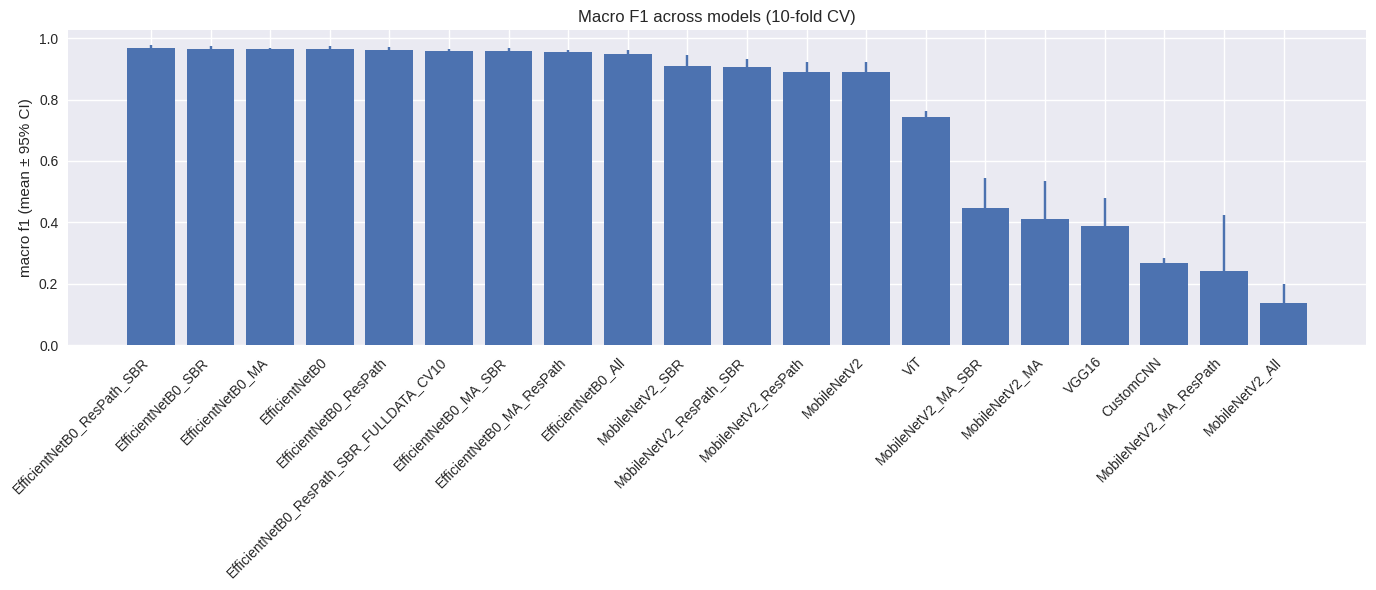

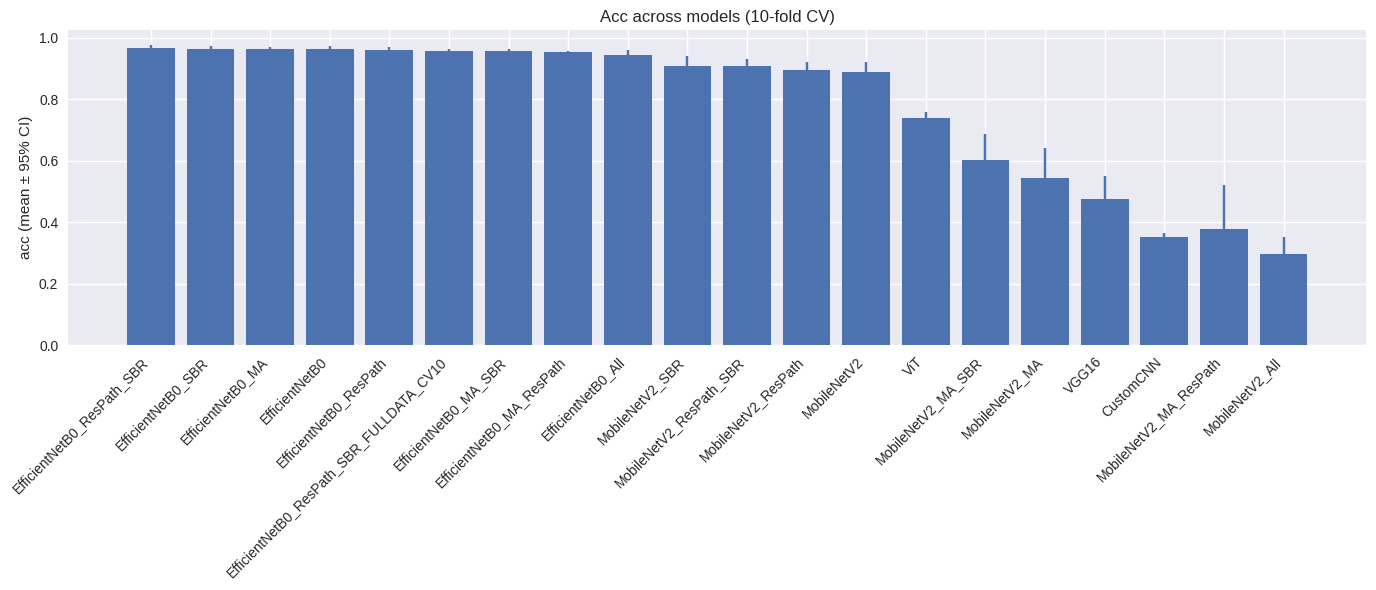

In [25]:
plt.style.use("seaborn-v0_8")

def plot_metric_bar_with_ci(summary_df, metric="macro_f1", top_n=None):
    df = summary_df.copy()
    if top_n is not None:
        df = df.head(top_n)

    x = np.arange(len(df))
    means = df[f"{metric}_mean"].values
    lows  = df[f"{metric}_ci_low"].values
    highs = df[f"{metric}_ci_high"].values
    errs  = np.vstack([means - lows, highs - means])

    plt.figure(figsize=(14, 6))
    plt.bar(x, means)
    plt.errorbar(x, means, yerr=errs, fmt="none", capsize=4)
    plt.xticks(x, df.index, rotation=45, ha="right")
    plt.ylabel(metric.replace("_", " ") + " (mean ± 95% CI)")
    plt.title(f"{metric.replace('_', ' ').title()} across models (10-fold CV)")
    plt.tight_layout()
    plt.show()

plot_metric_bar_with_ci(model_summary, metric="macro_f1", top_n=None)
plot_metric_bar_with_ci(model_summary, metric="acc", top_n=None)

/tmp/ipykernel_142390/888376376.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top10_models, showmeans=True)


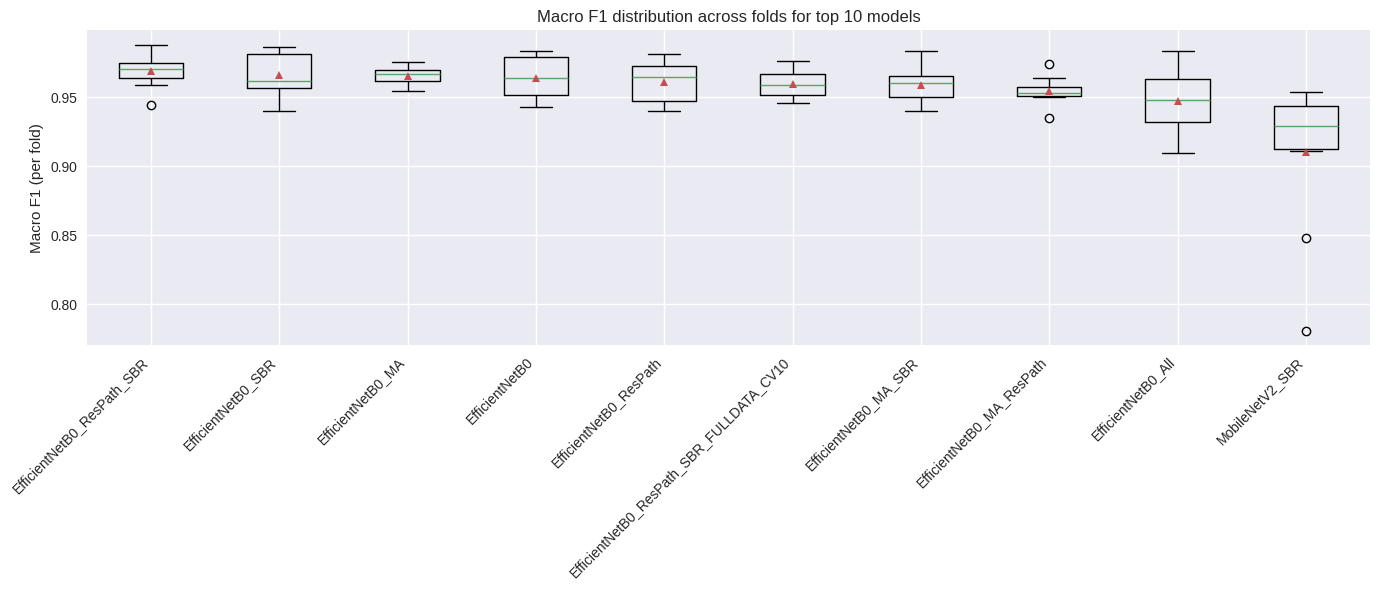

In [26]:
top10_models = model_summary.head(10).index.tolist()
top10_kfold = kfold_df[kfold_df["model"].isin(top10_models)]

plt.figure(figsize=(14, 6))
data = [top10_kfold[top10_kfold["model"] == m]["macro_f1"].values for m in top10_models]
plt.boxplot(data, labels=top10_models, showmeans=True)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1 (per fold)")
plt.title("Macro F1 distribution across folds for top 10 models")
plt.tight_layout()
plt.show()

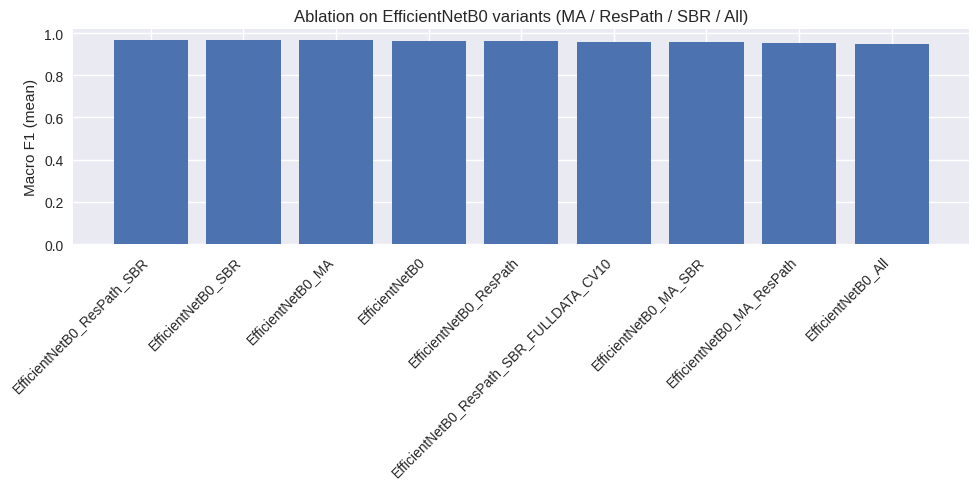


=== EfficientNetB0 ablation: Δ Macro-F1 vs base ===
EfficientNetB0_ResPath_SBR  Macro-F1 mean: 0.9692  Δ vs base: +0.0053
EfficientNetB0_SBR         Macro-F1 mean: 0.9657  Δ vs base: +0.0018
EfficientNetB0_MA          Macro-F1 mean: 0.9653  Δ vs base: +0.0015
EfficientNetB0             Macro-F1 mean: 0.9639  Δ vs base: +0.0000
EfficientNetB0_ResPath     Macro-F1 mean: 0.9612  Δ vs base: -0.0027
EfficientNetB0_ResPath_SBR_FULLDATA_CV10  Macro-F1 mean: 0.9597  Δ vs base: -0.0041
EfficientNetB0_MA_SBR      Macro-F1 mean: 0.9589  Δ vs base: -0.0050
EfficientNetB0_MA_ResPath  Macro-F1 mean: 0.9542  Δ vs base: -0.0097
EfficientNetB0_All         Macro-F1 mean: 0.9474  Δ vs base: -0.0165


In [27]:
eff_mask = model_summary["backbone"] == "EfficientNetB0"
eff_summary = model_summary[eff_mask].copy()

plt.figure(figsize=(10, 5))
x = np.arange(len(eff_summary))
plt.bar(x, eff_summary["macro_f1_mean"].values)
plt.xticks(x, eff_summary.index, rotation=45, ha="right")
plt.ylabel("Macro F1 (mean)")
plt.title("Ablation on EfficientNetB0 variants (MA / ResPath / SBR / All)")
plt.tight_layout()
plt.show()

if "EfficientNetB0" in eff_summary.index:
    base_f1 = eff_summary.loc["EfficientNetB0", "macro_f1_mean"]
    print("\n=== EfficientNetB0 ablation: Δ Macro-F1 vs base ===")
    for name, row in eff_summary.iterrows():
        delta = row["macro_f1_mean"] - base_f1
        print(f"{name:25s}  Macro-F1 mean: {row['macro_f1_mean']:.4f}  Δ vs base: {delta:+.4f}")

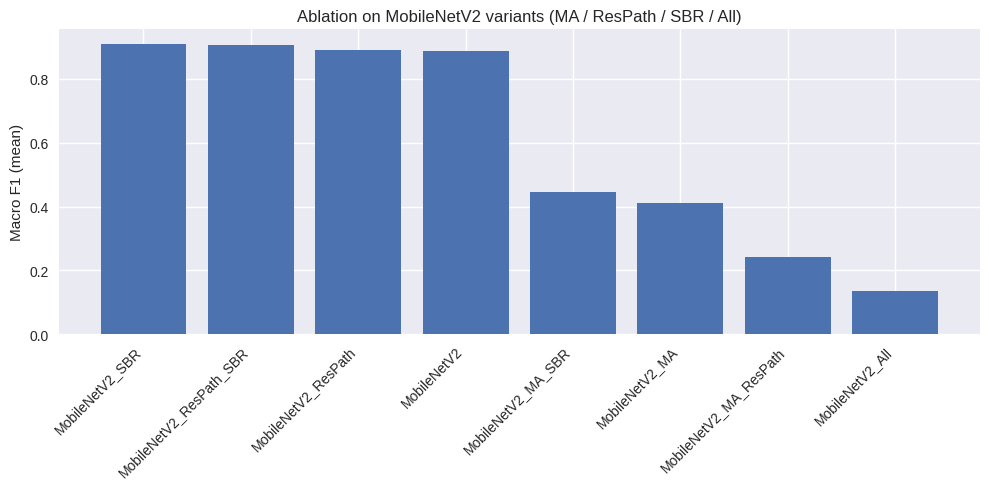


=== MobileNetV2 ablation: Δ Macro-F1 vs base ===
MobileNetV2_SBR            Macro-F1 mean: 0.9101  Δ vs base: +0.0210
MobileNetV2_ResPath_SBR    Macro-F1 mean: 0.9077  Δ vs base: +0.0187
MobileNetV2_ResPath        Macro-F1 mean: 0.8906  Δ vs base: +0.0016
MobileNetV2                Macro-F1 mean: 0.8890  Δ vs base: +0.0000
MobileNetV2_MA_SBR         Macro-F1 mean: 0.4470  Δ vs base: -0.4420
MobileNetV2_MA             Macro-F1 mean: 0.4100  Δ vs base: -0.4790
MobileNetV2_MA_ResPath     Macro-F1 mean: 0.2424  Δ vs base: -0.6466
MobileNetV2_All            Macro-F1 mean: 0.1369  Δ vs base: -0.7521


In [28]:
mob_mask = model_summary["backbone"] == "MobileNetV2"
mob_summary = model_summary[mob_mask].copy()

plt.figure(figsize=(10, 5))
x = np.arange(len(mob_summary))
plt.bar(x, mob_summary["macro_f1_mean"].values)
plt.xticks(x, mob_summary.index, rotation=45, ha="right")
plt.ylabel("Macro F1 (mean)")
plt.title("Ablation on MobileNetV2 variants (MA / ResPath / SBR / All)")
plt.tight_layout()
plt.show()

if "MobileNetV2" in mob_summary.index:
    base_f1_m = mob_summary.loc["MobileNetV2", "macro_f1_mean"]
    print("\n=== MobileNetV2 ablation: Δ Macro-F1 vs base ===")
    for name, row in mob_summary.iterrows():
        delta = row["macro_f1_mean"] - base_f1_m
        print(f"{name:25s}  Macro-F1 mean: {row['macro_f1_mean']:.4f}  Δ vs base: {delta:+.4f}")

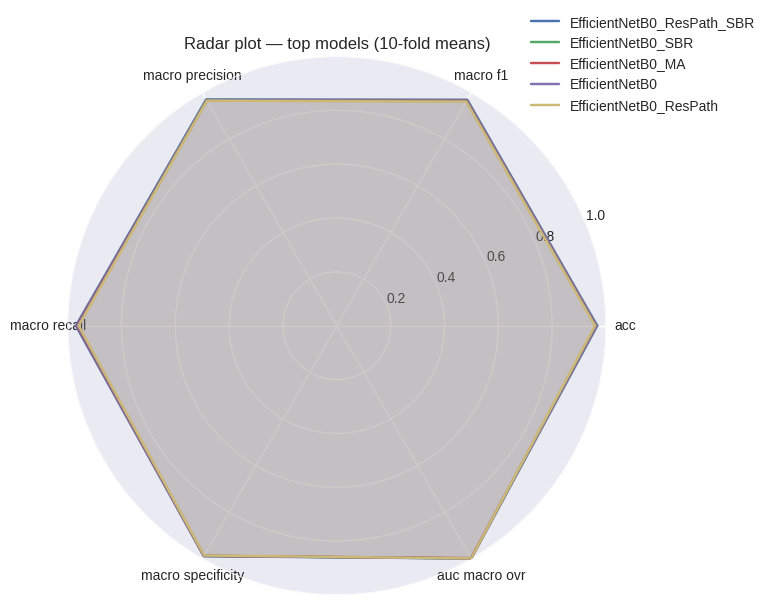

In [29]:
def radar_plot_top_models(summary_df, top_n=5):
    top_models = summary_df.head(top_n)
    metrics_for_radar = ["acc", "macro_f1", "macro_precision", "macro_recall", "macro_specificity", "auc_macro_ovr"]

    labels = [m.replace("_", " ") for m in metrics_for_radar]
    num_vars = len(metrics_for_radar)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for model_name, row in top_models.iterrows():
        values = [row[m + "_mean"] for m in metrics_for_radar]
        values += values[:1]
        ax.plot(angles, values, label=model_name)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title("Radar plot — top models (10-fold means)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

radar_plot_top_models(model_summary, top_n=5)

In [30]:
def get_top_k_models(k):
    return model_summary.head(k).index.tolist()

print("Top models by CV Macro-F1:")
print(model_summary.head(10)[["macro_f1_mean"]])

X_tr_full = train_paths      
y_tr_full = y_all            

print(f"\nFULL TRAINING SET SIZE: {len(X_tr_full)} images (100% of training set)")

builder_dict = dict(all_builders)


def train_one_model_full(model_name):
    print(f"\n========== FULL TRAINING (100% TRAIN): {model_name} ==========")

    build_fn = builder_dict[model_name]
    model, base_core = build_fn()

    backbone_name = "ViT" if model_name == "ViT" else model_name.split("_")[0]

    train_ds = make_ds(X_tr_full, y_tr_full, backbone_name, training=True)

    opt = keras.optimizers.Adam(3e-4)
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

    print("Training head (warm-up)...")
    hist1 = model.fit(
        train_ds,
        epochs=EPOCHS_WARMUP,
        verbose=2,
        shuffle=True
    )

    if base_core is not None:
        base_core.trainable = True
        if isinstance(base_core.layers, list) and len(base_core.layers) > NUM_FINE_TUNE_LAYERS:
            for l in base_core.layers[:-NUM_FINE_TUNE_LAYERS]:
                l.trainable = False

        opt2 = keras.optimizers.Adam(1e-5)
        model.compile(optimizer=opt2, loss="categorical_crossentropy", metrics=["accuracy"])

        print("Fine-tuning backbone...")
        hist2 = model.fit(
            train_ds,
            epochs=EPOCHS_FINETUNE,
            verbose=2,
            shuffle=True
        )

        history = {}
        for k, v in hist1.history.items():
            history[k] = list(v)
        for k, v in hist2.history.items():
            history.setdefault(k, [])
            history[k] += list(v)

    else:
        history = hist1.history

    print(f"Finished training: {model_name}")
    return model, history

def train_top_k_models(k):
    models = get_top_k_models(k)
    print(f"\n=== TRAINING TOP-{k} MODELS (FULL TRAIN SET) ===")
    for m in models: print(" -", m)

    trained = {}
    histories = {}

    for m in models:
        mod, hist = train_one_model_full(m)
        trained[m] = mod
        histories[m] = hist

    print(f"=== Finished training top-{k} models ===")
    return trained, histories

full_trained_models_top2, full_histories_top2 = train_top_k_models(2)
full_trained_models_top3, full_histories_top3 = train_top_k_models(3)
full_trained_models_top5, full_histories_top5 = train_top_k_models(5)

print("\n=== SUMMARY ===")
print("Top-2 models:", list(full_trained_models_top2.keys()))
print("Top-3 models:", list(full_trained_models_top3.keys()))
print("Top-5 models:", list(full_trained_models_top5.keys()))


Top models by CV Macro-F1:
                                          macro_f1_mean
model                                                  
EfficientNetB0_ResPath_SBR                     0.969186
EfficientNetB0_SBR                             0.965670
EfficientNetB0_MA                              0.965343
EfficientNetB0                                 0.963888
EfficientNetB0_ResPath                         0.961213
EfficientNetB0_ResPath_SBR_FULLDATA_CV10       0.959748
EfficientNetB0_MA_SBR                          0.958889
EfficientNetB0_MA_ResPath                      0.954214
EfficientNetB0_All                             0.947369
MobileNetV2_SBR                                0.910050

FULL TRAINING SET SIZE: 2870 images (100% of training set)

=== TRAINING TOP-2 MODELS (FULL TRAIN SET) ===
 - EfficientNetB0_ResPath_SBR
 - EfficientNetB0_SBR

========== FULL TRAINING (100% TRAIN): EfficientNetB0_ResPath_SBR ==========
Training head (warm-up)...
Epoch 1/5
90/90 - 71s - loss: 0.5141

KeyboardInterrupt: 

In [ ]:
SAVE_DIR = os.path.join(os.getcwd(), "saved_models")
os.makedirs(SAVE_DIR, exist_ok=True)

def save_model_group(models, group_name):
    print(f"\n=== Saving {group_name} models ===")
    for name, model in models.items():
        path = os.path.join(SAVE_DIR, f"{name}_fulltrain.h5")
        model.save(path)
        print("Saved:", path)

save_model_group(full_trained_models_top2, "Top-2")
save_model_group(full_trained_models_top3, "Top-3")
save_model_group(full_trained_models_top5, "Top-5")

print("\n=== ALL MODELS SAVED ===")

In [31]:
def load_group(names):
    loaded = {}
    for m in names:
        path = os.path.join("saved_models", f"{m}_fulltrain.h5")
        print("Loading:", path)
        loaded[m] = load_model(path)
    return loaded

top2_names = list(full_trained_models_top2.keys())
top3_names = list(full_trained_models_top3.keys())
top5_names = list(full_trained_models_top5.keys())

loaded_top2 = load_group(top2_names)
loaded_top3 = load_group(top3_names)
loaded_top5 = load_group(top5_names)

print("\n=== MODELS LOADED ===")

NameError: name 'full_trained_models_top2' is not defined

In [27]:
def eval_group_on_test(models):
    metrics = {}
    probs   = {}

    for name, model in models.items():
        backbone = "ViT" if name == "ViT" else name.split("_")[0]
        print(f"\n=== TEST EVAL: {name} ===")
        res = evaluate_model(model, backbone, "test", test_paths, y_test)
        
        metrics[name] = res
        probs[name]   = res["probs"]
        
        print(f"Acc={res['acc']:.4f} | F1={res['macro_f1']:.4f} | AUC={res['auc_macro_ovr']:.4f}")

    return metrics, probs

test_metrics_top2, test_probs_top2 = eval_group_on_test(loaded_top2)
test_metrics_top3, test_probs_top3 = eval_group_on_test(loaded_top3)
test_metrics_top5, test_probs_top5 = eval_group_on_test(loaded_top5)

print("\n=== TEST EVALUATION COMPLETE ===")


=== TEST EVAL: EfficientNetB0 ===
Acc=0.8249 | F1=0.8002 | AUC=0.9604

=== TEST EVAL: EfficientNetB0_SBR ===
Acc=0.8046 | F1=0.7730 | AUC=0.9657

=== TEST EVAL: EfficientNetB0 ===
Acc=0.8249 | F1=0.8002 | AUC=0.9604

=== TEST EVAL: EfficientNetB0_SBR ===
Acc=0.8046 | F1=0.7730 | AUC=0.9657

=== TEST EVAL: EfficientNetB0_MA ===
Acc=0.7995 | F1=0.7651 | AUC=0.9504

=== TEST EVAL: EfficientNetB0 ===
Acc=0.8249 | F1=0.8002 | AUC=0.9604

=== TEST EVAL: EfficientNetB0_SBR ===
Acc=0.8046 | F1=0.7730 | AUC=0.9657

=== TEST EVAL: EfficientNetB0_MA ===
Acc=0.7995 | F1=0.7651 | AUC=0.9504

=== TEST EVAL: EfficientNetB0_ResPath_SBR ===
Acc=0.8350 | F1=0.8180 | AUC=0.9527

=== TEST EVAL: EfficientNetB0_ResPath ===
Acc=0.7995 | F1=0.7696 | AUC=0.9480

=== TEST EVALUATION COMPLETE ===


In [37]:
train_probs_full = {}   

def compute_train_probs(models_dict):
    for mname, model in models_dict.items():
        backbone = "ViT" if mname == "ViT" else mname.split("_")[0]
        print(f"Computing TRAIN probabilities for: {mname}")

        ds = tf.data.Dataset.from_tensor_slices(train_paths)

        def _map(p):
            im = tf_load_image(p)
            im = preprocess_switch(im, backbone)
            return im

        ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        probs = model.predict(ds, verbose=0)
        train_probs_full[mname] = probs

        print(f"Stored TRAIN probs for {mname}: shape={probs.shape}")

compute_train_probs(loaded_top2)
compute_train_probs(loaded_top3)
compute_train_probs(loaded_top5)

print("\n=== TRAIN PROBABILITIES READY ===")

Computing TRAIN probabilities for: EfficientNetB0
Stored TRAIN probs for EfficientNetB0: shape=(2870, 4)
Computing TRAIN probabilities for: EfficientNetB0_SBR
Stored TRAIN probs for EfficientNetB0_SBR: shape=(2870, 4)
Computing TRAIN probabilities for: EfficientNetB0
Stored TRAIN probs for EfficientNetB0: shape=(2870, 4)
Computing TRAIN probabilities for: EfficientNetB0_SBR
Stored TRAIN probs for EfficientNetB0_SBR: shape=(2870, 4)
Computing TRAIN probabilities for: EfficientNetB0_MA
Stored TRAIN probs for EfficientNetB0_MA: shape=(2870, 4)
Computing TRAIN probabilities for: EfficientNetB0
Stored TRAIN probs for EfficientNetB0: shape=(2870, 4)
Computing TRAIN probabilities for: EfficientNetB0_SBR
Stored TRAIN probs for EfficientNetB0_SBR: shape=(2870, 4)
Computing TRAIN probabilities for: EfficientNetB0_MA
Stored TRAIN probs for EfficientNetB0_MA: shape=(2870, 4)
Computing TRAIN probabilities for: EfficientNetB0_ResPath_SBR
Stored TRAIN probs for EfficientNetB0_ResPath_SBR: shape=(2870

In [38]:
def ensemble_soft_voting(model_names, probs_dict):
    probs_list = [probs_dict[m] for m in model_names]
    P, metrics = evaluate_probs(probs_list, y_test)
    return P, metrics


def run_ensemble(name, model_names, probs_dict):
    print(f"\n=== ENSEMBLE: {name} ===")
    
    P, metrics = ensemble_soft_voting(model_names, probs_dict)

    for k, v in metrics.items():
        if k != "specificity_per_class":
            print(f"{k}: {v:.4f}")

    return P, metrics


ensemble_top2_P, ensemble_top2_metrics = run_ensemble("Top-2", top2_names, test_probs_top2)
ensemble_top3_P, ensemble_top3_metrics = run_ensemble("Top-3", top3_names, test_probs_top3)
ensemble_top5_P, ensemble_top5_metrics = run_ensemble("Top-5", top5_names, test_probs_top5)


np.save("ensemble_top2_probs.npy", ensemble_top2_P)
np.save("ensemble_top3_probs.npy", ensemble_top3_P)
np.save("ensemble_top5_probs.npy", ensemble_top5_P)

print("\n=== ENSEMBLES SAVED ===")


=== ENSEMBLE: Top-2 ===
acc: 0.8223
macro_f1: 0.7958
macro_precision: 0.8766
macro_recall: 0.8250
macro_specificity: 0.9383
auc_macro_ovr: 0.9650

=== ENSEMBLE: Top-3 ===
acc: 0.8071
macro_f1: 0.7813
macro_precision: 0.8712
macro_recall: 0.8047
macro_specificity: 0.9329
auc_macro_ovr: 0.9679

=== ENSEMBLE: Top-5 ===
acc: 0.8096
macro_f1: 0.7854
macro_precision: 0.8731
macro_recall: 0.8072
macro_specificity: 0.9337
auc_macro_ovr: 0.9705

=== ENSEMBLES SAVED ===


In [43]:
def weighted_soft_voting(model_names, probs_dict, model_summary):
    weights = np.array([model_summary.loc[m]["macro_f1_mean"] for m in model_names])
    weights = weights / weights.sum()

    P = np.zeros_like(probs_dict[model_names[0]])

    for w, m in zip(weights, model_names):
        P += w * probs_dict[m]

    y_pred = P.argmax(axis=1)
    metrics = compute_full_metrics(y_test, y_pred, P, num_classes)

    return P, metrics, weights


def run_weighted_ensemble(name, model_names, probs_dict):
    print(f"\n=== WEIGHTED ENSEMBLE: {name} ===")
    
    P, metrics, weights = weighted_soft_voting(model_names, probs_dict, model_summary)

    print("Weights:", dict(zip(model_names, weights.round(4))))
    for k, v in metrics.items():
        if k != "specificity_per_class":
            print(f"{k}: {v:.4f}")

    return P, metrics, weights


weighted_top2_P, weighted_top2_metrics, weights2 = run_weighted_ensemble("Top-2", top2_names, test_probs_top2)
weighted_top3_P, weighted_top3_metrics, weights3 = run_weighted_ensemble("Top-3", top3_names, test_probs_top3)
weighted_top5_P, weighted_top5_metrics, weights5 = run_weighted_ensemble("Top-5", top5_names, test_probs_top5)


=== WEIGHTED ENSEMBLE: Top-2 ===
Weights: {'EfficientNetB0': 0.5009, 'EfficientNetB0_SBR': 0.4991}
acc: 0.8223
macro_f1: 0.7958
macro_precision: 0.8766
macro_recall: 0.8250
macro_specificity: 0.9383
auc_macro_ovr: 0.9650

=== WEIGHTED ENSEMBLE: Top-3 ===
Weights: {'EfficientNetB0': 0.3342, 'EfficientNetB0_SBR': 0.333, 'EfficientNetB0_MA': 0.3329}
acc: 0.8071
macro_f1: 0.7813
macro_precision: 0.8712
macro_recall: 0.8047
macro_specificity: 0.9329
auc_macro_ovr: 0.9679

=== WEIGHTED ENSEMBLE: Top-5 ===
Weights: {'EfficientNetB0': 0.2009, 'EfficientNetB0_SBR': 0.2001, 'EfficientNetB0_MA': 0.2001, 'EfficientNetB0_ResPath_SBR': 0.1998, 'EfficientNetB0_ResPath': 0.1992}
acc: 0.8096
macro_f1: 0.7854
macro_precision: 0.8731
macro_recall: 0.8072
macro_specificity: 0.9337
auc_macro_ovr: 0.9705


In [39]:
def build_meta_features(models, train_probs_dict, test_probs_dict):
    X_train = np.concatenate([train_probs_dict[m] for m in models], axis=1)
    X_test  = np.concatenate([test_probs_dict[m]  for m in models], axis=1)
    return X_train, X_test

In [41]:
stack_models = top5_names
X_train_meta, X_test_meta = build_meta_features(stack_models, train_probs_full, test_probs_top5)
y_train_meta, y_test_meta = y_all, y_test

meta_models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, multi_class="multinomial"))
    ]),
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", probability=True))
    ]),
    "RBF_SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ])
}

extended_stack_results = {}

print("\n=== CLASSIFIER ABLATION ON TOP-5 STACKING FEATURES ===")

for name, clf in meta_models.items():
    print(f"\n--- {name} ---")
    clf.fit(X_train_meta, y_train_meta)
    probs = clf.predict_proba(X_test_meta)
    y_pred = probs.argmax(axis=1)
    metrics = compute_full_metrics(y_test_meta, y_pred, probs, num_classes)
    extended_stack_results[name] = metrics

    for k, v in metrics.items():
        if k != "specificity_per_class":
            print(f"{k}: {v:.4f}")



=== CLASSIFIER ABLATION ON TOP-5 STACKING FEATURES ===

--- LR ---
acc: 0.8096
macro_f1: 0.7883
macro_precision: 0.8778
macro_recall: 0.8064
macro_specificity: 0.9335
auc_macro_ovr: 0.9223

--- LinearSVM ---
acc: 0.8096
macro_f1: 0.7861
macro_precision: 0.8752
macro_recall: 0.8072
macro_specificity: 0.9336
auc_macro_ovr: 0.9461

--- RBF_SVM ---
acc: 0.8122
macro_f1: 0.7914
macro_precision: 0.8777
macro_recall: 0.8089
macro_specificity: 0.9344
auc_macro_ovr: 0.9242

--- RandomForest ---


/home/lateral/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


acc: 0.8096
macro_f1: 0.7885
macro_precision: 0.8785
macro_recall: 0.8064
macro_specificity: 0.9334
auc_macro_ovr: 0.9411

--- GradientBoosting ---
acc: 0.8046
macro_f1: 0.7808
macro_precision: 0.8752
macro_recall: 0.8014
macro_specificity: 0.9317
auc_macro_ovr: 0.9020

--- MLP ---
acc: 0.8020
macro_f1: 0.7764
macro_precision: 0.8725
macro_recall: 0.7989
macro_specificity: 0.9309
auc_macro_ovr: 0.9133

--- KNN ---
acc: 0.8071
macro_f1: 0.7837
macro_precision: 0.8746
macro_recall: 0.8039
macro_specificity: 0.9327
auc_macro_ovr: 0.8725


In [47]:
X_train_meta2, X_test_meta2 = build_meta_features(top2_names, train_probs_full, test_probs_top2)
X_train_meta3, X_test_meta3 = build_meta_features(top3_names, train_probs_full, test_probs_top3)
X_train_meta5, X_test_meta5 = build_meta_features(top5_names, train_probs_full, test_probs_top5)

all_meta_models = {
    "LR": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, multi_class="multinomial"))]),
    "LinearSVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="linear", probability=True))]),
    "RBF_SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", probability=True))]),
    "RandomForest": RandomForestClassifier(n_estimators=300, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300),
    "MLP": Pipeline([("scaler", StandardScaler()), ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=7))])
}

stack2_probs = {}
stack3_probs = {}
stack5_probs = {}

print("\n=== TRAINING META-MODELS FOR TOP-2/TOP-3/TOP-5 ===")

for name, clf in all_meta_models.items():
    print(f"Training {name} on Top-2")
    clf.fit(X_train_meta2, y_all)
    stack2_probs[name] = clf.predict_proba(X_test_meta2)

for name, clf in all_meta_models.items():
    print(f"Training {name} on Top-3")
    clf.fit(X_train_meta3, y_all)
    stack3_probs[name] = clf.predict_proba(X_test_meta3)

for name, clf in all_meta_models.items():
    print(f"Training {name} on Top-5")
    clf.fit(X_train_meta5, y_all)
    stack5_probs[name] = clf.predict_proba(X_test_meta5)


=== TRAINING META-MODELS FOR TOP-2/TOP-3/TOP-5 ===
Training LR on Top-2
Training LinearSVM on Top-2
Training RBF_SVM on Top-2
Training RandomForest on Top-2


/home/lateral/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training GradientBoosting on Top-2
Training MLP on Top-2
Training KNN on Top-2
Training LR on Top-3
Training LinearSVM on Top-3
Training RBF_SVM on Top-3
Training RandomForest on Top-3


/home/lateral/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training GradientBoosting on Top-3
Training MLP on Top-3
Training KNN on Top-3
Training LR on Top-5
Training LinearSVM on Top-5
Training RBF_SVM on Top-5
Training RandomForest on Top-5


/home/lateral/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training GradientBoosting on Top-5
Training MLP on Top-5
Training KNN on Top-5


In [48]:
def blend_ensemble(soft_probs, stacked_probs, alpha=0.5):
    P = alpha * soft_probs + (1 - alpha) * stacked_probs
    y_pred = P.argmax(axis=1)
    metrics = compute_full_metrics(y_test, y_pred, P, num_classes)
    return P, metrics


def run_hybrid_group(group_name, soft_probs, stack_probs_dict):
    print(f"\n========== HYBRID ENSEMBLES — {group_name} ==========")
    results = {}

    for clf_name, clf_probs in stack_probs_dict.items():
        print(f"\n--- Hybrid {group_name} + {clf_name} ---")

        P, metrics = blend_ensemble(soft_probs, clf_probs, alpha=0.5)
        results[clf_name] = metrics

        for k, v in metrics.items():
            if k != "specificity_per_class":
                print(f"{k}: {v:.4f}")

    return results

hybrid_top2_results = run_hybrid_group("Top-2", ensemble_top2_P, stack2_probs)
hybrid_top3_results = run_hybrid_group("Top-3", ensemble_top3_P, stack3_probs)
hybrid_top5_results = run_hybrid_group("Top-5", ensemble_top5_P, stack5_probs)


========== HYBRID ENSEMBLES — Top-2 ==========

--- Hybrid Top-2 + LR ---
acc: 0.8071
macro_f1: 0.7812
macro_precision: 0.8706
macro_recall: 0.8047
macro_specificity: 0.9329
auc_macro_ovr: 0.9487

--- Hybrid Top-2 + LinearSVM ---
acc: 0.8071
macro_f1: 0.7810
macro_precision: 0.8705
macro_recall: 0.8047
macro_specificity: 0.9329
auc_macro_ovr: 0.9579

--- Hybrid Top-2 + RBF_SVM ---
acc: 0.8071
macro_f1: 0.7819
macro_precision: 0.8730
macro_recall: 0.8047
macro_specificity: 0.9328
auc_macro_ovr: 0.9683

--- Hybrid Top-2 + RandomForest ---
acc: 0.8096
macro_f1: 0.7876
macro_precision: 0.8762
macro_recall: 0.8064
macro_specificity: 0.9336
auc_macro_ovr: 0.9681

--- Hybrid Top-2 + GradientBoosting ---
acc: 0.8020
macro_f1: 0.7787
macro_precision: 0.8702
macro_recall: 0.7962
macro_specificity: 0.9310
auc_macro_ovr: 0.9649

--- Hybrid Top-2 + MLP ---
acc: 0.8046
macro_f1: 0.7798
macro_precision: 0.8731
macro_recall: 0.8014
macro_specificity: 0.9318
auc_macro_ovr: 0.9541

--- Hybrid Top-2 + K

In [60]:
metrics_keys = [
    "acc",
    "macro_f1",
    "macro_precision",
    "macro_recall",
    "macro_specificity",
    "auc_macro_ovr",
]

def add_rows_from_metrics_dict(rows, metrics_dict, group, family=None):
    for name, m in metrics_dict.items():
        row = {
            "name": name,
            "group": group,
            "family": family,
        }
        for k in metrics_keys:
            row[k] = m.get(k, None)
        rows.append(row)

rows = []

all_model_metrics = {}
for d in (test_metrics_top2, test_metrics_top3, test_metrics_top5):
    all_model_metrics.update(d)

add_rows_from_metrics_dict(rows, all_model_metrics, group="model", family="individual")

soft_ensembles = {
    "Soft Top-2": ensemble_top2_metrics,
    "Soft Top-3": ensemble_top3_metrics,
    "Soft Top-5": ensemble_top5_metrics,
}
add_rows_from_metrics_dict(rows, soft_ensembles, group="ensemble_soft")

weighted_ensembles = {
    "Weighted Top-2": weighted_top2_metrics,
    "Weighted Top-3": weighted_top3_metrics,
    "Weighted Top-5": weighted_top5_metrics,
}
add_rows_from_metrics_dict(rows, weighted_ensembles, group="ensemble_weighted")

stacked_top5_metrics = {
    f"Top-5 Stacked ({name})": m
    for name, m in extended_stack_results.items()
}
add_rows_from_metrics_dict(rows, stacked_top5_metrics, group="ensemble_stacked", family="Top-5")

hybrid_groups = {
    "Top-2": hybrid_top2_results,
    "Top-3": hybrid_top3_results,
    "Top-5": hybrid_top5_results,
}

for fam, res_dict in hybrid_groups.items():
    hybrid_named = {
        f"{fam} Hybrid ({name})": m
        for name, m in res_dict.items()
    }
    add_rows_from_metrics_dict(rows, hybrid_named, group="ensemble_hybrid", family=fam)

comparison_df = pd.DataFrame(rows)

comparison_df = (
    comparison_df.sort_values("macro_f1", ascending=False)
                 .drop_duplicates(subset=["name"], keep="first")
                 .reset_index(drop=True)
)

print("Comparison DF shape:", comparison_df.shape)
display(comparison_df.round(4))

Comparison DF shape: (39, 9)


,name,group,family,acc,macro_f1,macro_precision,macro_recall,macro_specificity,auc_macro_ovr
0,EfficientNetB0_ResPath_SBR,model,individual,0.8350,0.8180,0.8922,0.8375,0.9423,0.9527
1,EfficientNetB0,model,individual,0.8249,0.8002,0.8794,0.8275,0.9391,0.9604
2,Soft Top-2,ensemble_soft,None,0.8223,0.7958,0.8766,0.8250,0.9383,0.9650
3,Weighted Top-2,ensemble_weighted,None,0.8223,0.7958,0.8766,0.8250,0.9383,0.9650
4,Top-5 Hybrid (LinearSVM),ensemble_hybrid,Top-5,0.8147,0.7939,0.8788,0.8122,0.9353,0.9667
5,Top-5 Hybrid (RBF_SVM),ensemble_hybrid,Top-5,0.8122,0.7914,0.8777,0.8089,0.9344,0.9690
6,Top-5 Stacked (RBF_SVM),ensemble_stacked,Top-5,0.8122,0.7914,0.8777,0.8089,0.9344,0.9242
7,Top-5 Hybrid (RandomForest),ensemble_hybrid,Top-5,0.8122,0.7908,0.8788,0.8097,0.9344,0.9704
8,Top-5 Hybrid (LR),ensemble_hybrid,Top-5,0.8122,0.7908,0.8788,0.8097,0.9344,0.9645
9,Top-5 Stacked (RandomForest),ensemble_stacked,Top-5,0.8096,0.7885,0.8785,0.8064,0.9334,0.9411


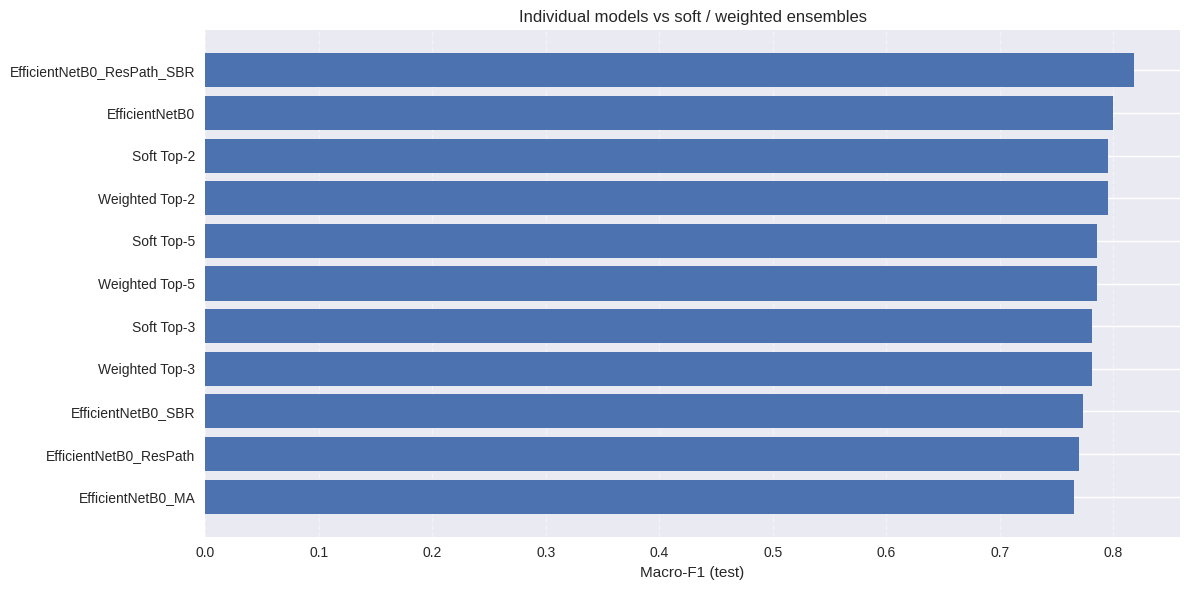

In [61]:
plt.figure(figsize=(12, 6))

subset = comparison_df[
    comparison_df["group"].isin(["model", "ensemble_soft", "ensemble_weighted"])
].copy()

subset = subset.sort_values("macro_f1", ascending=False)

plt.barh(subset["name"], subset["macro_f1"])
plt.xlabel("Macro-F1 (test)")
plt.title("Individual models vs soft / weighted ensembles")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

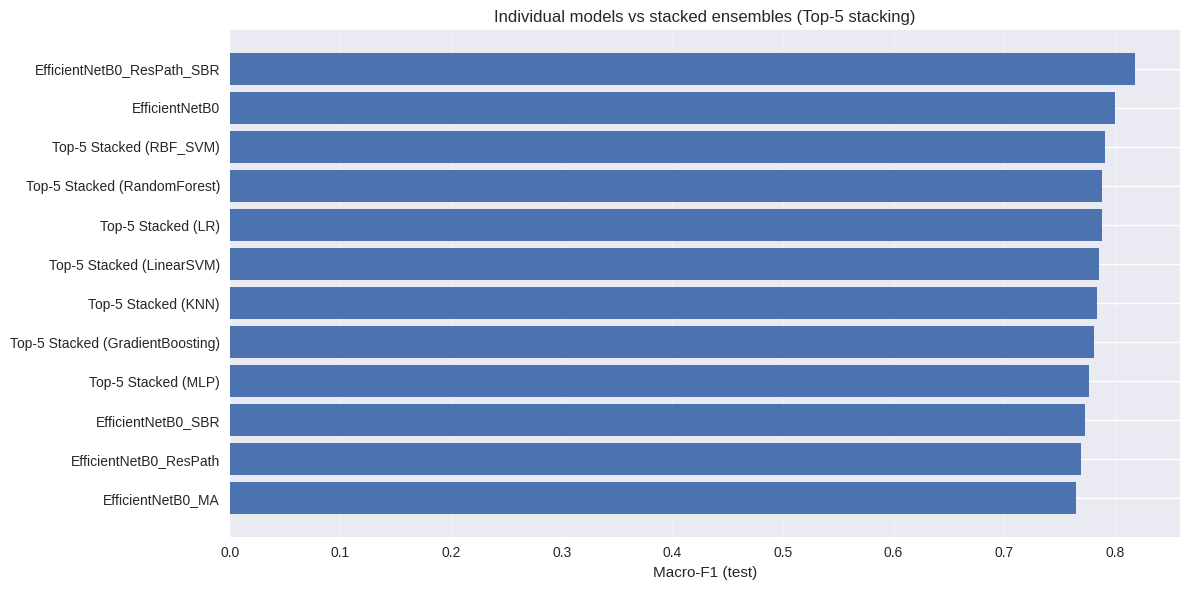

In [62]:
plt.figure(figsize=(12, 6))

subset = comparison_df[
    (comparison_df["group"].isin(["model", "ensemble_stacked"]))
].copy()

subset = subset.sort_values("macro_f1", ascending=False)

plt.barh(subset["name"], subset["macro_f1"])
plt.xlabel("Macro-F1 (test)")
plt.title("Individual models vs stacked ensembles (Top-5 stacking)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

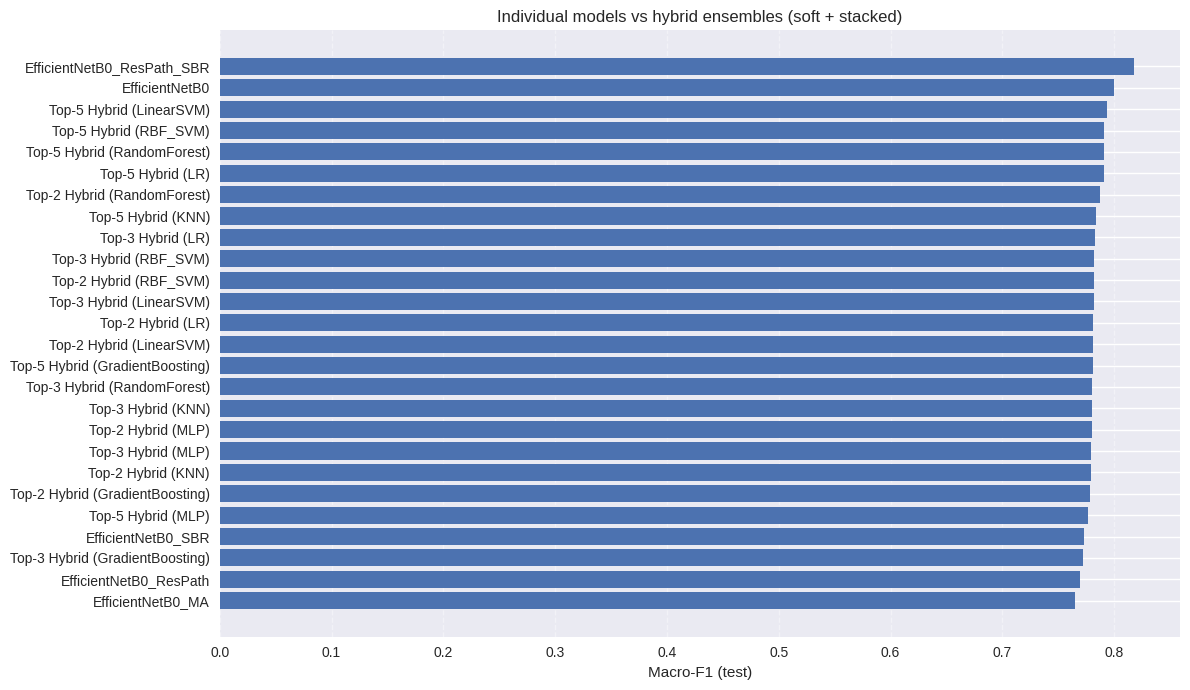

In [63]:
plt.figure(figsize=(12, 7))

subset = comparison_df[
    comparison_df["group"].isin(["model", "ensemble_hybrid"])
].copy()

subset = subset.sort_values("macro_f1", ascending=False)

plt.barh(subset["name"], subset["macro_f1"])
plt.xlabel("Macro-F1 (test)")
plt.title("Individual models vs hybrid ensembles (soft + stacked)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

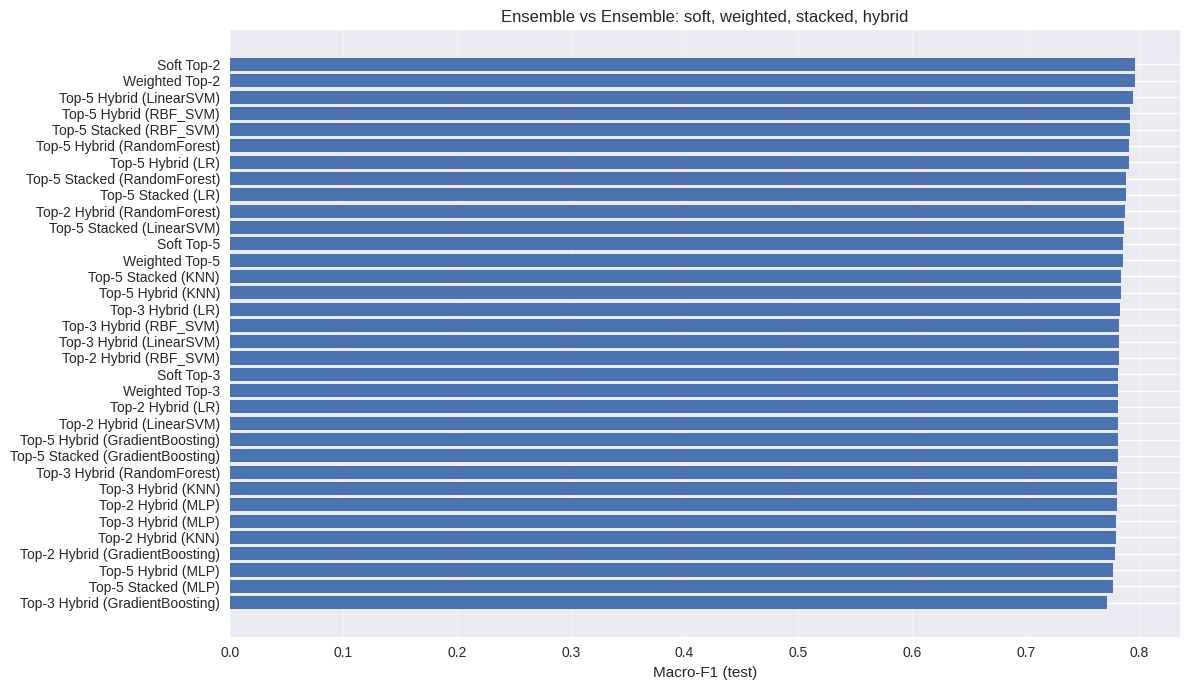

In [64]:
plt.figure(figsize=(12, 7))

subset = comparison_df[
    comparison_df["group"].str.startswith("ensemble_")
].copy()

subset = subset.sort_values("macro_f1", ascending=False)

plt.barh(subset["name"], subset["macro_f1"])
plt.xlabel("Macro-F1 (test)")
plt.title("Ensemble vs Ensemble: soft, weighted, stacked, hybrid")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [69]:
BEST_MODEL_NAME = "EfficientNetB0_ResPath_SBR"

best_model_path = os.path.join("saved_models", f"{BEST_MODEL_NAME}_fulltrain.h5")
print("Loading best model from:", best_model_path)
best_model = load_model(best_model_path)

def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

last_conv_layer_name = get_last_conv_layer_name(best_model)
print("Using last conv layer for Grad-CAM:", last_conv_layer_name)

Loading best model from: saved_models/EfficientNetB0_ResPath_SBR_fulltrain.h5
Using last conv layer for Grad-CAM: conv2d_20


In [86]:
def load_image_rgb(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = resize_with_pad_cv(img, IMG_SIZE)
    return img

In [87]:
def compute_gradcam(model, img_tensor, layer_name=None):
    if layer_name is None:
        layer_name = get_last_conv_layer_name(model)
    conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model([model.inputs], [conv_layer.output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.tensordot(conv_outputs, pooled_grads, axes=1)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)
    heatmap = cv2.resize(heatmap.numpy(), (IMG_SIZE, IMG_SIZE))
    return heatmap

def overlay_cam_on_image(img_rgb, cam, alpha=0.4):
    heatmap = np.uint8(255*cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return np.uint8(alpha*heatmap + (1-alpha)*img_rgb)

In [89]:
!pip install lime -q

In [90]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def lime_predict(images):
    imgs = (np.array(images)*255).astype(np.uint8)
    batch = []
    for im in imgs:
        t = tf.convert_to_tensor(im)
        t = preprocess_switch(t, "EfficientNetB0")
        batch.append(t.numpy())
    batch = np.stack(batch, axis=0)
    preds = best_model.predict(batch, verbose=0)
    return preds

lime_explainer = lime_image.LimeImageExplainer()

In [116]:
LIME_ROOT = os.path.join(os.getcwd(), "gradcam_lime")
TEST_LIME_ROOT = os.path.join(LIME_ROOT, "Testing")

os.makedirs(TEST_LIME_ROOT, exist_ok=True)

test_classes = sorted(set(test_labels))
for cls in test_classes:
    os.makedirs(os.path.join(TEST_LIME_ROOT, cls), exist_ok=True)

TEST_LIME_ROOT

'/home/lateral/brain-tumor/gradcam_lime/Testing'

In [92]:
def process_and_save_test_image_gradcam_lime(model, img_path, label):
    img_rgb = load_image_rgb(img_path)
    if img_rgb is None or not isinstance(img_rgb, np.ndarray) or img_rgb.size == 0:
        raise ValueError("Image load failed")

    img_tensor = tf.convert_to_tensor(img_rgb)
    img_tensor = preprocess_switch(img_tensor, "EfficientNetB0")
    img_tensor = tf.expand_dims(img_tensor, axis=0)

    cam = compute_gradcam(model, img_tensor, layer_name=last_conv_layer_name)
    cam_overlay = overlay_cam_on_image(img_rgb, cam)

    img_lime = img_rgb.astype(np.float32) / 255.0
    preds_single = lime_predict([img_lime])[0]
    pred_label = int(np.argmax(preds_single))

    explanation = lime_explainer.explain_instance(
        img_lime,
        lime_predict,
        top_labels=len(le.classes_),
        hide_color=0,
        num_samples=1000
    )

    lime_img, lime_mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    lime_img_uint8 = (lime_img * 255).astype(np.uint8)
    boundaries = mark_boundaries(img_lime, lime_mask)
    boundaries_uint8 = (boundaries * 255).astype(np.uint8)
    lime_mask_uint8 = (lime_mask > 0).astype(np.uint8) * 255

    cls_dir = os.path.join(TEST_LIME_ROOT, label)
    base = os.path.basename(img_path)
    stem, ext = os.path.splitext(base)

    cv2.imwrite(os.path.join(cls_dir, f"{stem}_orig{ext}"), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_gradcam_overlay{ext}"), cv2.cvtColor(cam_overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_lime_image{ext}"), cv2.cvtColor(lime_img_uint8, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_lime_boundaries{ext}"), cv2.cvtColor(boundaries_uint8, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_lime_mask.png"), lime_mask_uint8)

In [93]:
num_test = len(test_paths)
print(f"Processing {num_test} test images...")

for idx, (p, lbl) in enumerate(zip(test_paths, test_labels), start=1):
    try:
        process_and_save_test_image_gradcam_lime(best_model, p, lbl)
    except Exception as e:
        print(f"[ERROR] {p} -> {e}")
        continue

    if idx % 20 == 0 or idx == num_test:
        print(f"Processed {idx}/{num_test}")

print("DONE. Saved under:", TEST_LIME_ROOT)

Processing 394 test images...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Processed 394/394
DONE. Saved under: /home/lateral/brain-tumor/gradcam_lime/Testing


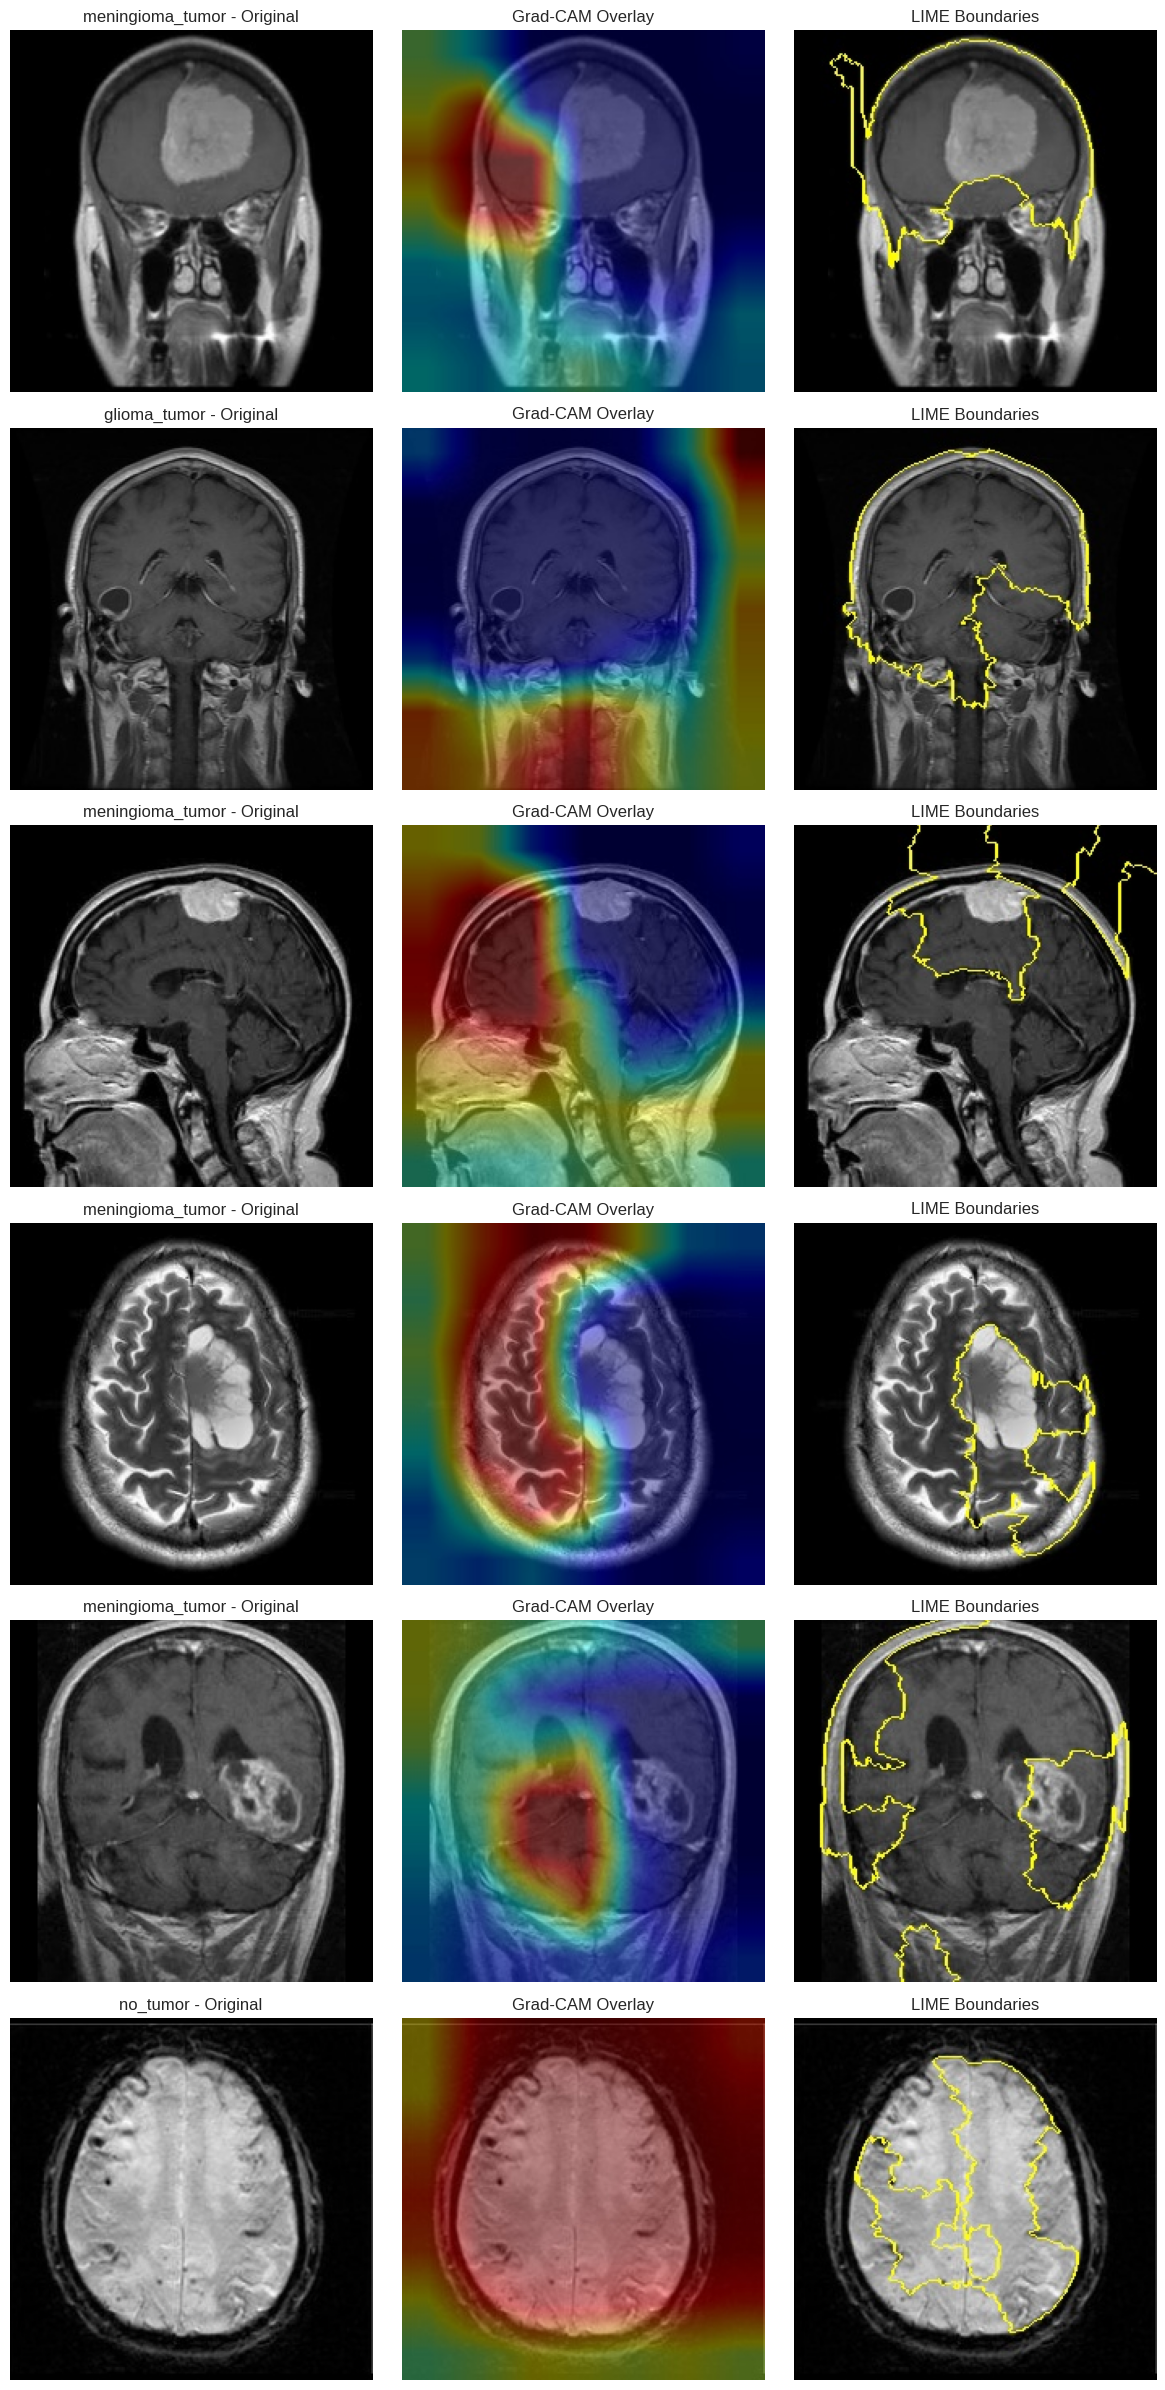

In [95]:
def visualize_gradcam_lime(n=6):
    paths = []
    for cls in test_classes:
        cls_dir = os.path.join(TEST_LIME_ROOT, cls)
        for f in os.listdir(cls_dir):
            if f.endswith("_orig.jpg") or f.endswith("_orig.png"):
                full = os.path.join(cls_dir, f)
                paths.append((full, cls))

    random.shuffle(paths)
    samples = paths[:n]

    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

    for i, (orig_path, lbl) in enumerate(samples):
        base = os.path.basename(orig_path).replace("_orig", "")
        stem, ext = os.path.splitext(base)

        cls_dir = os.path.join(TEST_LIME_ROOT, lbl)

        cam_path  = os.path.join(cls_dir, f"{stem}_gradcam_overlay{ext}")
        limeb_path = os.path.join(cls_dir, f"{stem}_lime_boundaries{ext}")

        orig  = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
        cam   = cv2.cvtColor(cv2.imread(cam_path),  cv2.COLOR_BGR2RGB)
        limeb = cv2.cvtColor(cv2.imread(limeb_path), cv2.COLOR_BGR2RGB)

        axes[i,0].imshow(orig);  axes[i,0].set_title(f"{lbl} - Original");  axes[i,0].axis("off")
        axes[i,1].imshow(cam);   axes[i,1].set_title("Grad-CAM Overlay");  axes[i,1].axis("off")
        axes[i,2].imshow(limeb); axes[i,2].set_title("LIME Boundaries");   axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_gradcam_lime(6)

In [117]:
def compute_gradcam_pp(model, img_tensor, layer_name=None):
    if layer_name is None:
        layer_name = get_last_conv_layer_name(model)
    conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model([model.inputs], [conv_layer.output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    grads2 = grads**2
    grads3 = grads2*grads
    global_sum = tf.reduce_sum(conv_outputs*grads3, axis=(1,2), keepdims=True)
    alpha = grads2 / (2.0*grads2 + global_sum + 1e-10)
    weights = tf.reduce_sum(alpha*tf.nn.relu(grads), axis=(1,2))
    cam = tf.reduce_sum(weights[..., tf.newaxis, tf.newaxis, :]*conv_outputs, axis=-1)[0]
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-10)
    cam = cv2.resize(cam.numpy(), (IMG_SIZE, IMG_SIZE))
    return cam

def overlay_cam_on_image(img_rgb, cam, alpha=0.4):
    heatmap = np.uint8(255*cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return np.uint8(alpha*heatmap + (1-alpha)*img_rgb)

def cam_to_binary_mask(cam, thresh_factor=0.3):
    cam_blur = cv2.GaussianBlur(cam, (11,11), 0)
    mask = (cam_blur > (thresh_factor * cam_blur.max())).astype(np.uint8) * 255
    k = np.ones((9,9), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    mask = cv2.dilate(mask, k, iterations=2)
    return mask

In [118]:
def compute_guided_backprop(model, img_tensor, class_idx=None):
    x = tf.cast(img_tensor, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        preds = model(x)
        if class_idx is None:
            class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, x)[0]
    grads = tf.nn.relu(grads)
    g = grads.numpy()
    g = (g - g.min()) / (g.max() - g.min() + 1e-10)
    return g

def compute_guided_gradcam(model, img_tensor, cam_pp):
    gb = compute_guided_backprop(model, img_tensor)
    gb_gray = np.max(gb, axis=-1)
    gb_gray = (gb_gray - gb_gray.min()) / (gb_gray.max() - gb_gray.min() + 1e-10)
    gb_resized = cv2.resize(gb_gray, (IMG_SIZE, IMG_SIZE))
    gg = cam_pp * gb_resized
    gg = (gg - gg.min()) / (gg.max() - gg.min() + 1e-10)
    return gg

In [119]:
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic

def lime_segmenter(image):
    return slic(image, n_segments=100, compactness=10, sigma=1)

def lime_predict(images):
    imgs = (np.array(images)*255).astype(np.uint8)
    batch = []
    for im in imgs:
        t = tf.convert_to_tensor(im)
        t = preprocess_switch(t, "EfficientNetB0")
        batch.append(t.numpy())
    batch = np.stack(batch, axis=0)
    preds = best_model.predict(batch, verbose=0)
    return preds

lime_explainer = lime_image.LimeImageExplainer()

def process_and_save_test_image_gradcam_lime_pp(model, img_path, label):
    img_rgb = load_image_rgb(img_path)
    if img_rgb is None or not isinstance(img_rgb, np.ndarray) or img_rgb.size == 0:
        raise ValueError("Image load failed")

    img_tensor = tf.convert_to_tensor(img_rgb)
    img_tensor = preprocess_switch(img_tensor, "EfficientNetB0")
    img_tensor = tf.expand_dims(img_tensor, axis=0)

    cam_pp = compute_gradcam_pp(model, img_tensor, layer_name=last_conv_layer_name)
    cam_overlay = overlay_cam_on_image(img_rgb, cam_pp)

    img_lime = img_rgb.astype(np.float32) / 255.0
    preds_single = lime_predict([img_lime])[0]
    pred_label = int(np.argmax(preds_single))

    explanation = lime_explainer.explain_instance(
        img_lime,
        lime_predict,
        top_labels=len(le.classes_),
        hide_color=0,
        num_samples=2000,
        segmentation_fn=lime_segmenter
    )

    lime_img, lime_mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=True,
        num_features=7,
        hide_rest=False
    )

    lime_img_uint8 = (lime_img * 255).astype(np.uint8)
    boundaries = mark_boundaries(img_lime, lime_mask)
    boundaries_uint8 = (boundaries * 255).astype(np.uint8)
    lime_mask_uint8 = (lime_mask > 0).astype(np.uint8) * 255

    cls_dir = os.path.join(TEST_LIME_ROOT, label)
    base = os.path.basename(img_path)
    stem, ext = os.path.splitext(base)

    cv2.imwrite(os.path.join(cls_dir, f"{stem}_orig{ext}"), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_gradcampp_overlay{ext}"), cv2.cvtColor(cam_overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_lime_image{ext}"), cv2.cvtColor(lime_img_uint8, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_lime_boundaries{ext}"), cv2.cvtColor(boundaries_uint8, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_lime_mask.png"), lime_mask_uint8)

In [120]:
num_test = len(test_paths)
print(f"Processing {num_test} test images with Grad-CAM++ + improved LIME...")

for idx, (p, lbl) in enumerate(zip(test_paths, test_labels), start=1):
    try:
        process_and_save_test_image_gradcam_lime_pp(best_model, p, lbl)
    except Exception as e:
        print(f"[ERROR] {p} -> {e}")
        continue
    if idx % 10 == 0 or idx == num_test:
        print(f"Processed {idx}/{num_test}")

print("DONE. Saved under:", TEST_LIME_ROOT)

Processing 394 test images with Grad-CAM++ + improved LIME...


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Processed 394/394
DONE. Saved under: /home/lateral/brain-tumor/gradcam_lime/Testing


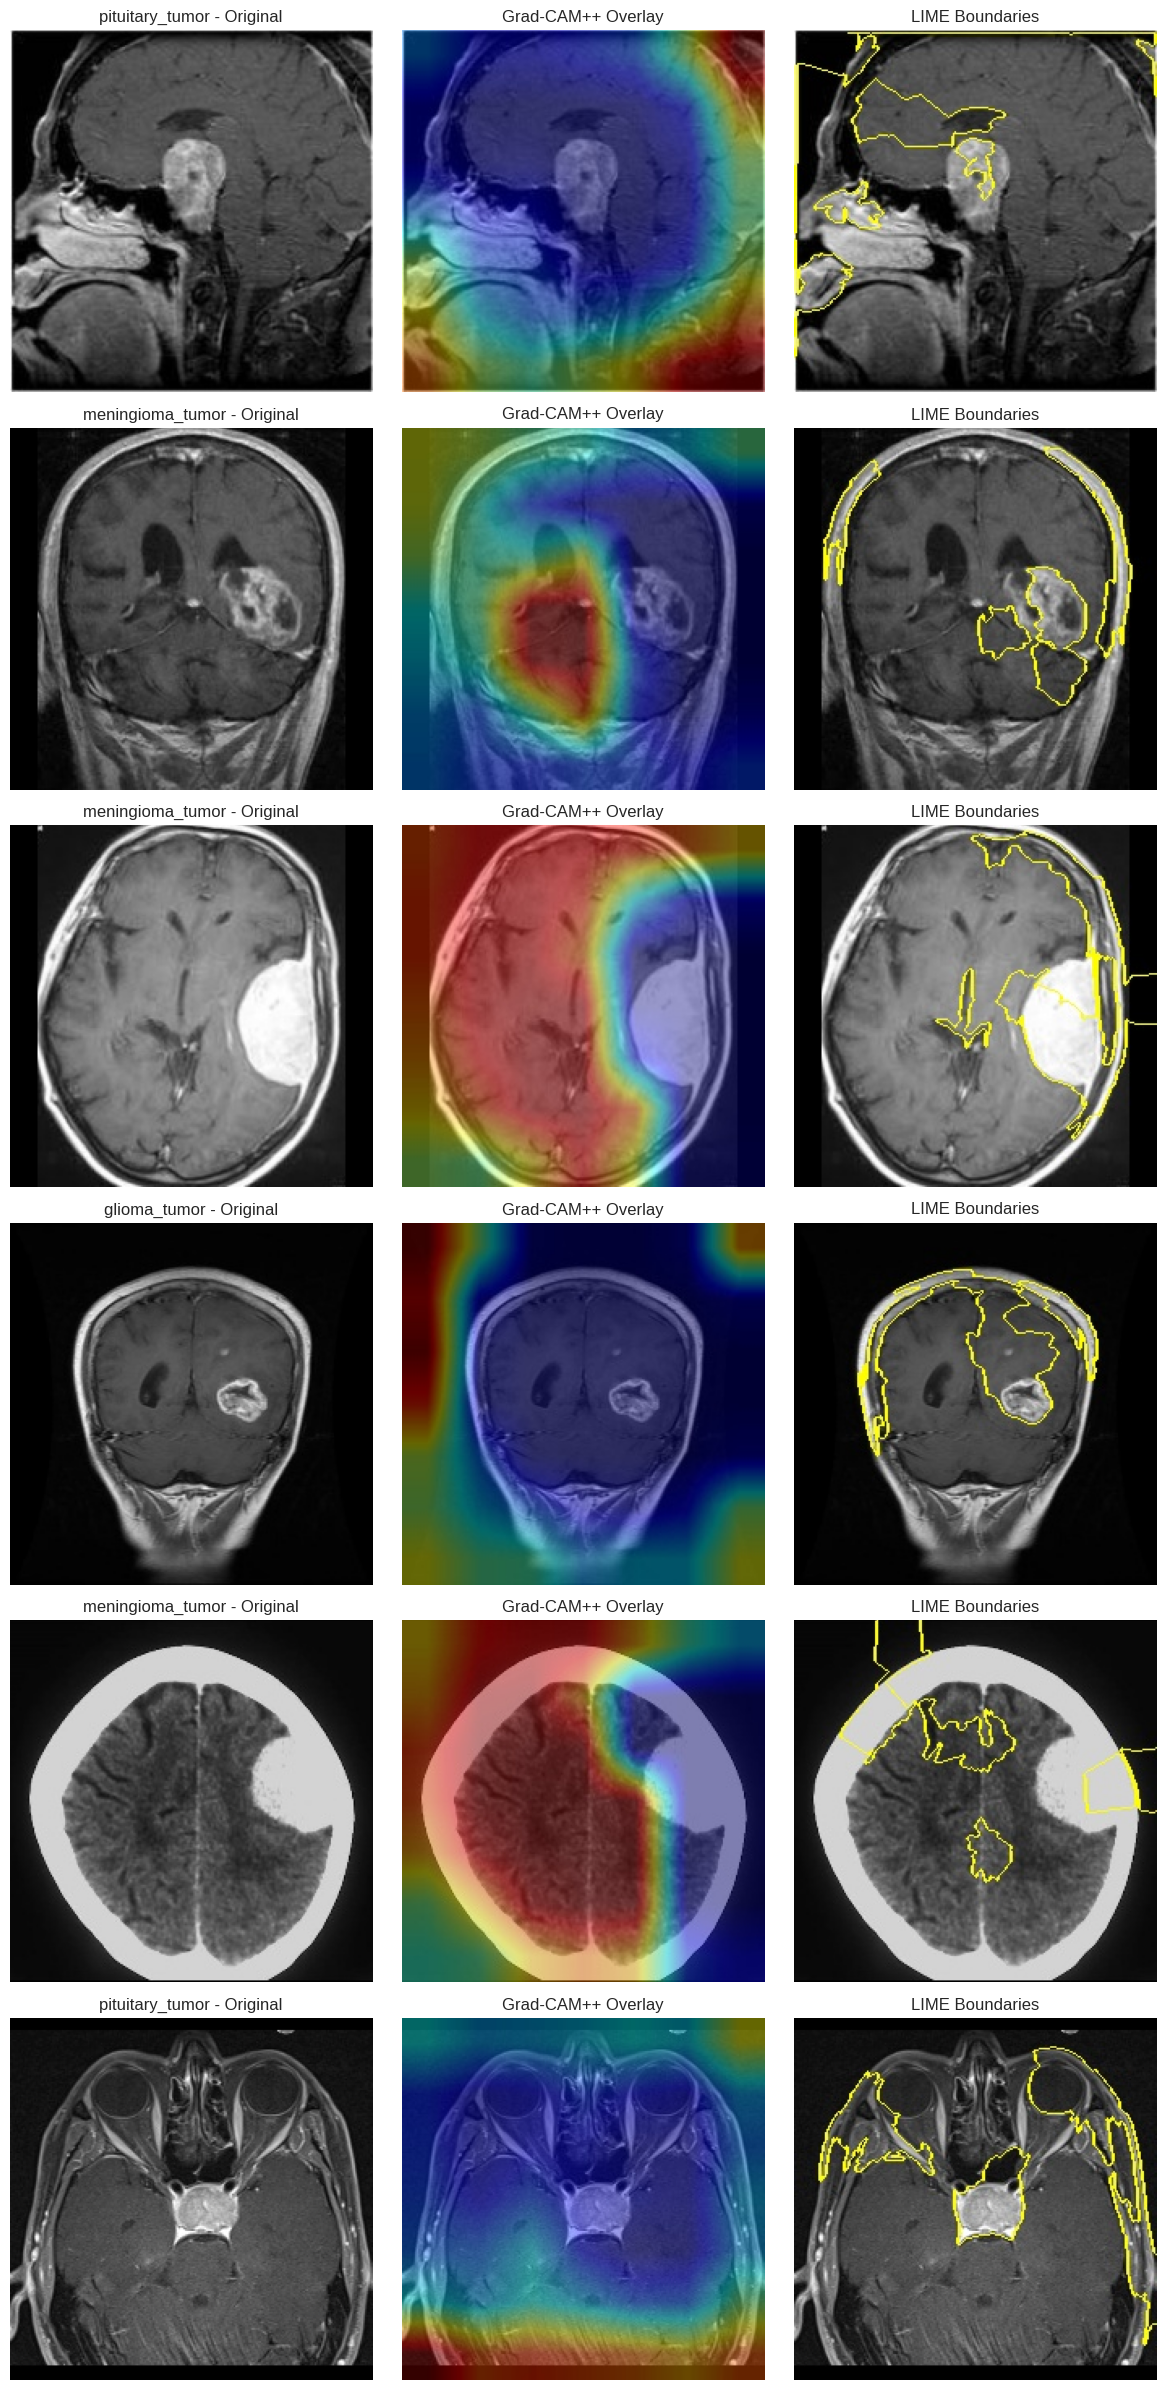

In [125]:
import random

def visualize_gradcampp_lime(n=6):
    paths = []
    for cls in test_classes:
        cls_dir = os.path.join(TEST_LIME_ROOT, cls)
        for f in os.listdir(cls_dir):
            if f.endswith("_orig.jpg") or f.endswith("_orig.png"):
                full = os.path.join(cls_dir, f)
                paths.append((full, cls))

    random.shuffle(paths)
    samples = paths[:n]

    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

    for i, (orig_path, lbl) in enumerate(samples):
        base = os.path.basename(orig_path).replace("_orig", "")
        stem, ext = os.path.splitext(base)
        cls_dir = os.path.join(TEST_LIME_ROOT, lbl)

        cam_path   = os.path.join(cls_dir, f"{stem}_gradcampp_overlay{ext}")
        limeb_path = os.path.join(cls_dir, f"{stem}_lime_boundaries{ext}")

        orig  = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
        cam   = cv2.cvtColor(cv2.imread(cam_path),  cv2.COLOR_BGR2RGB)
        limeb = cv2.cvtColor(cv2.imread(limeb_path), cv2.COLOR_BGR2RGB)

        axes[i,0].imshow(orig)
        axes[i,0].set_title(f"{lbl} - Original")
        axes[i,0].axis("off")

        axes[i,1].imshow(cam)
        axes[i,1].set_title("Grad-CAM++ Overlay")
        axes[i,1].axis("off")

        axes[i,2].imshow(limeb)
        axes[i,2].set_title("LIME Boundaries")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_gradcampp_lime(6)


In [126]:
def load_lime_mask_for_image(img_path, label):
    base = os.path.basename(img_path)
    stem, ext = os.path.splitext(base)
    mask_path = os.path.join(TEST_LIME_ROOT, label, f"{stem}_lime_mask.png")
    if not os.path.exists(mask_path):
        return None
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        return None
    m = (m > 0).astype(np.uint8) * 255
    return m

def cam_to_binary_mask(cam, thresh_factor=0.3):
    cam_blur = cv2.GaussianBlur(cam, (11,11), 0)
    mask = (cam_blur > (thresh_factor * cam_blur.max())).astype(np.uint8) * 255
    k = np.ones((9,9), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    mask = cv2.dilate(mask, k, iterations=2)
    return mask

def crop_with_mask(img_rgb, mask, margin=50):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return img_rgb
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    h, w = img_rgb.shape[:2]
    x1 = max(x1 - margin, 0)
    y1 = max(y1 - margin, 0)
    x2 = min(x2 + margin, w - 1)
    y2 = min(y2 + margin, h - 1)
    crop = img_rgb[y1:y2+1, x1:x2+1]
    crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
    return crop

In [127]:
y_true_list = []
probs_orig_list = []
probs_crop_list = []
valid_indices = []

for idx, (p, lbl, y_true) in enumerate(zip(test_paths, test_labels, y_test)):
    img_rgb = load_image_rgb(p)
    if img_rgb is None or not isinstance(img_rgb, np.ndarray) or img_rgb.size == 0:
        continue

    img_tensor = tf.convert_to_tensor(img_rgb)
    img_tensor = preprocess_switch(img_tensor, "EfficientNetB0")
    img_tensor = tf.expand_dims(img_tensor, axis=0)

    preds_orig = best_model.predict(img_tensor, verbose=0)[0]

    cam_pp = compute_gradcam_pp(best_model, img_tensor, layer_name=last_conv_layer_name)
    cam_mask = cam_to_binary_mask(cam_pp, 0.3)
    lime_mask = load_lime_mask_for_image(p, lbl)
    fused_mask = fuse_cam_lime_masks(cam_mask, lime_mask)

    crop_rgb = crop_with_mask(img_rgb, fused_mask)
    crop_tensor = tf.convert_to_tensor(crop_rgb)
    crop_tensor = preprocess_switch(crop_tensor, "EfficientNetB0")
    crop_tensor = tf.expand_dims(crop_tensor, axis=0)

    preds_crop = best_model.predict(crop_tensor, verbose=0)[0]

    y_true_list.append(int(y_true))
    probs_orig_list.append(preds_orig)
    probs_crop_list.append(preds_crop)
    valid_indices.append(idx)

y_true_arr = np.array(y_true_list)
probs_orig_arr = np.vstack(probs_orig_list)
probs_crop_arr = np.vstack(probs_crop_list)

y_pred_orig = np.argmax(probs_orig_arr, axis=1)
y_pred_crop = np.argmax(probs_crop_arr, axis=1)

metrics_orig = compute_full_metrics(y_true_arr, y_pred_orig, probs_orig_arr, num_classes)
metrics_crop = compute_full_metrics(y_true_arr, y_pred_crop, probs_crop_arr, num_classes)

print("Original images metrics:")
for k, v in metrics_orig.items():
    if k != "specificity_per_class":
        print(k, "=", round(v, 4))

print("\nTumor-cropped images metrics (after improved fusion + crop):")
for k, v in metrics_crop.items():
    if k != "specificity_per_class":
        print(k, "=", round(v, 4))


Original images metrics:
acc = 0.8325
macro_f1 = 0.8136
macro_precision = 0.8889
macro_recall = 0.835
macro_specificity = 0.9415
auc_macro_ovr = 0.9534

Tumor-cropped images metrics (after improved fusion + crop):
acc = 0.7487
macro_f1 = 0.7094
macro_precision = 0.822
macro_recall = 0.7404
macro_specificity = 0.9133
auc_macro_ovr = 0.9386


In [128]:
FUSION_ROOT = os.path.join(os.getcwd(), "gradcam_lime_fusion")
TEST_FUSION_ROOT = os.path.join(FUSION_ROOT, "Testing")
os.makedirs(TEST_FUSION_ROOT, exist_ok=True)
for cls in test_classes:
    os.makedirs(os.path.join(TEST_FUSION_ROOT, cls), exist_ok=True)

for p, lbl in zip(test_paths, test_labels):
    img_rgb = load_image_rgb(p)
    if img_rgb is None or not isinstance(img_rgb, np.ndarray) or img_rgb.size == 0:
        continue

    img_tensor = tf.convert_to_tensor(img_rgb)
    img_tensor = preprocess_switch(img_tensor, "EfficientNetB0")
    img_tensor = tf.expand_dims(img_tensor, axis=0)

    cam_pp = compute_gradcam_pp(best_model, img_tensor, layer_name=last_conv_layer_name)
    cam_mask = cam_to_binary_mask(cam_pp, 0.6)
    lime_mask = load_lime_mask_for_image(p, lbl)
    fused_mask = fuse_cam_lime_masks(cam_mask, lime_mask)
    crop_rgb = crop_with_mask(img_rgb, fused_mask)

    cls_dir = os.path.join(TEST_FUSION_ROOT, lbl)
    base = os.path.basename(p)
    stem, ext = os.path.splitext(base)

    cv2.imwrite(os.path.join(cls_dir, f"{stem}_orig{ext}"), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_gradcampp{ext}"), cv2.cvtColor(overlay_cam_on_image(img_rgb, cam_pp), cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_fused_mask.png"), fused_mask)
    cv2.imwrite(os.path.join(cls_dir, f"{stem}_crop{ext}"), cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2BGR))

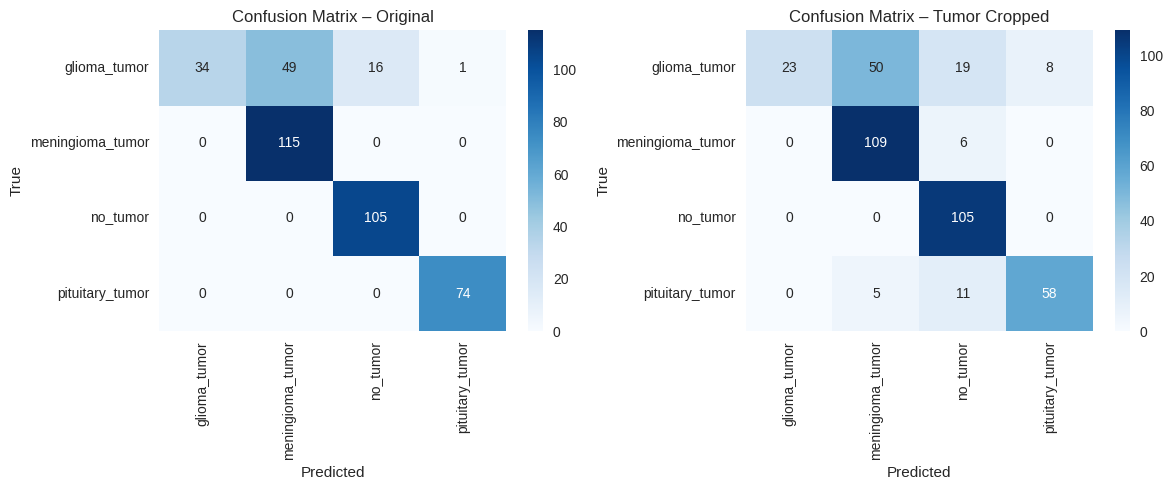

In [129]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_orig = confusion_matrix(y_true_arr, y_pred_orig)
cm_crop = confusion_matrix(y_true_arr, y_pred_crop)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm_orig, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix – Original")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1,2,2)
sns.heatmap(cm_crop, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix – Tumor Cropped")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

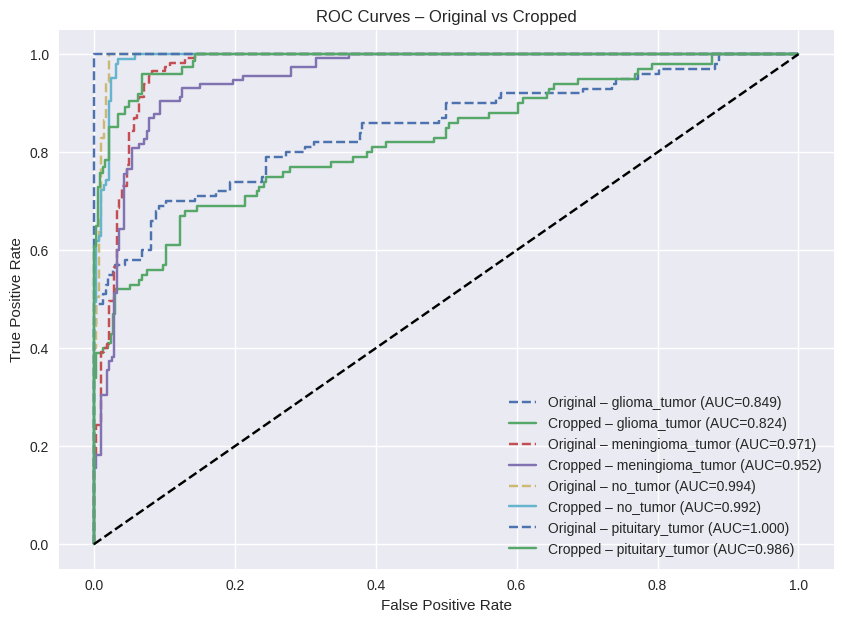

In [130]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true_arr, classes=list(range(num_classes)))

plt.figure(figsize=(10,7))

for i in range(num_classes):
    fpr_o, tpr_o, _ = roc_curve(y_true_bin[:, i], probs_orig_arr[:, i])
    fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, i], probs_crop_arr[:, i])
    auc_o = auc(fpr_o, tpr_o)
    auc_c = auc(fpr_c, tpr_c)
    plt.plot(fpr_o, tpr_o, label=f"Original – {le.classes_[i]} (AUC={auc_o:.3f})", linestyle="--")
    plt.plot(fpr_c, tpr_c, label=f"Cropped – {le.classes_[i]} (AUC={auc_c:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Original vs Cropped")
plt.legend()
plt.grid(True)
plt.show()

In [131]:
import pandas as pd

summary_compare = pd.DataFrame({
    "Metric": ["Accuracy","Macro F1","Macro Precision","Macro Recall","Macro Specificity","AUC"],
    "Original": [
        metrics_orig["acc"],
        metrics_orig["macro_f1"],
        metrics_orig["macro_precision"],
        metrics_orig["macro_recall"],
        metrics_orig["macro_specificity"],
        metrics_orig["auc_macro_ovr"]
    ],
    "Cropped": [
        metrics_crop["acc"],
        metrics_crop["macro_f1"],
        metrics_crop["macro_precision"],
        metrics_crop["macro_recall"],
        metrics_crop["macro_specificity"],
        metrics_crop["auc_macro_ovr"]
    ]
})

summary_compare = summary_compare.round(4)
summary_compare

,Metric,Original,Cropped
0,Accuracy,0.8325,0.7487
1,Macro F1,0.8136,0.7094
2,Macro Precision,0.8889,0.8220
3,Macro Recall,0.8350,0.7404
4,Macro Specificity,0.9415,0.9133
5,AUC,0.9534,0.9386


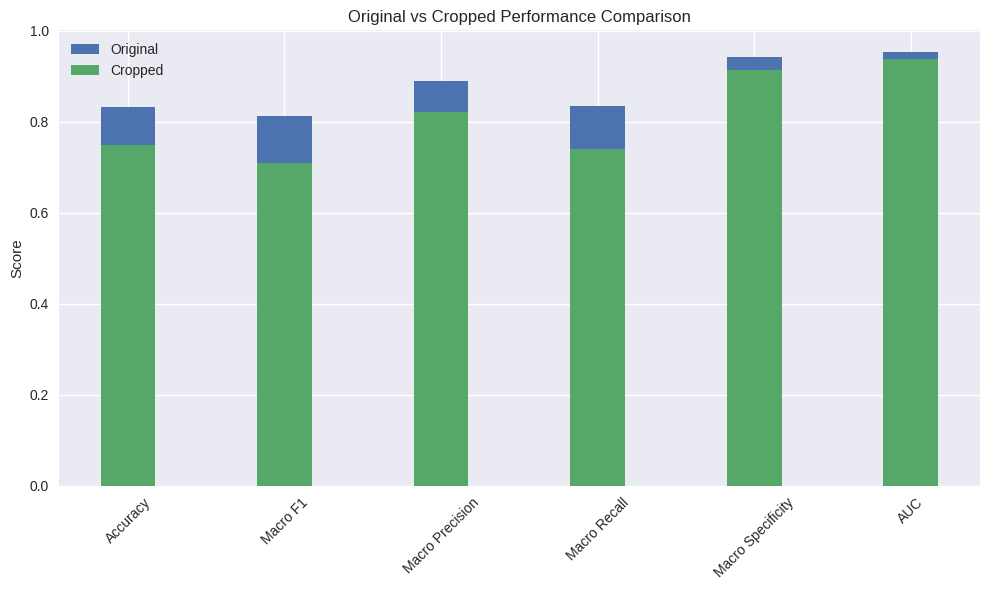

In [132]:
plt.figure(figsize=(10,6))
x = summary_compare["Metric"]
width = 0.35

plt.bar(x, summary_compare["Original"], width=width, label="Original")
plt.bar(x, summary_compare["Cropped"], width=width, label="Cropped", bottom=0)

plt.xticks(rotation=45)
plt.ylabel("Score")
plt.title("Original vs Cropped Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import tensorflow as tf

best_model_path = "saved_models/EfficientNetB0_ResPath_SBR_fulltrain.h5"
best_model = tf.keras.models.load_model(best_model_path, compile=False)

best_model_name = "EfficientNetB0_ResPath_SBR_fulltrain"
backbone = "EfficientNetB0"    

X_test = np.array(test_paths)
y_test_arr = np.array(y_test)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_results = []

print("\n=========== 10-FOLD CROSS-VALIDATION (TESTING ONLY) ===========\n")

for fold_idx, (_, test_idx) in enumerate(kf.split(X_test), start=1):

    print(f"=== Test Fold {fold_idx}/10 ===")

    fold_paths  = X_test[test_idx].tolist()
    fold_labels = y_test_arr[test_idx]

    res = evaluate_model(
        best_model,
        backbone,
        f"test_fold_{fold_idx}",
        fold_paths,
        fold_labels
    )

    fold_results.append({
        "fold": fold_idx,
        "acc": res["acc"],
        "macro_f1": res["macro_f1"],
        "auc_macro_ovr": res["auc_macro_ovr"],
        "macro_precision": res["macro_precision"],
        "macro_recall": res["macro_recall"],
        "macro_specificity": res["macro_specificity"]
    })

df_cv = pd.DataFrame(fold_results)
display(df_cv)

print("\n========= 10-FOLD TESTING SUMMARY =========")
for metric in ["acc", "macro_f1", "auc_macro_ovr",
               "macro_precision", "macro_recall", "macro_specificity"]:
    mean = df_cv[metric].mean()
    std  = df_cv[metric].std()
    print(f"{metric}: {mean:.4f} ± {std:.4f}")



=========== 10-FOLD CROSS-VALIDATION (TESTING ONLY) ===========

=== Test Fold 1/10 ===
=== Test Fold 2/10 ===
=== Test Fold 3/10 ===
=== Test Fold 4/10 ===
=== Test Fold 5/10 ===
=== Test Fold 6/10 ===
=== Test Fold 7/10 ===
=== Test Fold 8/10 ===
=== Test Fold 9/10 ===
=== Test Fold 10/10 ===


,fold,acc,macro_f1,auc_macro_ovr,macro_precision,macro_recall,macro_specificity
0,1,0.825000,0.847550,0.956050,0.902778,0.865385,0.939655
1,2,0.825000,0.802701,0.961866,0.809211,0.883333,0.938765
2,3,0.875000,0.851310,0.975099,0.907738,0.861111,0.958046
3,4,0.900000,0.837500,0.920731,0.930288,0.833333,0.963528
4,5,0.846154,0.836310,0.943619,0.899038,0.850000,0.945106
5,6,0.871795,0.781106,0.971356,0.930556,0.791667,0.951923
6,7,0.743590,0.723977,0.947531,0.837185,0.791667,0.912037
7,8,0.846154,0.836561,0.939398,0.902644,0.850000,0.946098
8,9,0.794872,0.744817,0.942950,0.854167,0.800000,0.929688
9,10,0.820513,0.790909,0.937196,0.916667,0.805556,0.930000



========= 10-FOLD TESTING SUMMARY =========
acc: 0.8348 ± 0.0445
macro_f1: 0.8053 ± 0.0447
auc_macro_ovr: 0.9496 ± 0.0166
macro_precision: 0.8890 ± 0.0412
macro_recall: 0.8332 ± 0.0337
macro_specificity: 0.9415 ± 0.0151


In [31]:
best_model_name = "EfficientNetB0_ResPath_SBR"

builder_dict = dict(all_builders)
best_build_fn = builder_dict[best_model_name]

all_paths_full  = train_paths + test_paths
all_labels_full = np.concatenate([y_all, y_test])

print(f"Total imagini pentru CV 10-fold (train+test): {len(all_paths_full)}")

best_kfold_results_full = kfold_train_evaluate(
    build_fn    = best_build_fn,
    model_label = best_model_name,
    all_paths   = all_paths_full,
    all_labels  = all_labels_full,
    n_splits    = 10
)

json_key = best_model_name + "_FULLDATA_CV10"
save_model_results_to_json(json_key, best_kfold_results_full)

best_kfold_df_full = pd.DataFrame(best_kfold_results_full)
display(best_kfold_df_full)

print("\n==== REZUMAT 10-FOLD CV (train+test) pentru", best_model_name, "====")
for metric in ["acc", "macro_f1", "macro_precision", "macro_recall","macro_specificity", "auc_macro_ovr"]:
    if metric in best_kfold_df_full.columns:
        m = best_kfold_df_full[metric].mean()
        s = best_kfold_df_full[metric].std()
        print(f"{metric}: {m:.4f} ± {s:.4f}")

Total imagini pentru CV 10-fold (train+test): 3264

=== EfficientNetB0_ResPath_SBR | Fold 1/10 ===
Epoch 1/5
92/92 - 81s - loss: 0.6084 - accuracy: 0.7903 - val_loss: 0.4627 - val_accuracy: 0.8991 - lr: 3.0000e-04 - 81s/epoch - 875ms/step
Epoch 2/5
92/92 - 65s - loss: 0.2582 - accuracy: 0.9033 - val_loss: 0.6619 - val_accuracy: 0.8593 - lr: 3.0000e-04 - 65s/epoch - 706ms/step
Epoch 3/5
92/92 - 61s - loss: 0.2151 - accuracy: 0.9231 - val_loss: 0.9619 - val_accuracy: 0.8226 - lr: 3.0000e-04 - 61s/epoch - 668ms/step
Epoch 4/5
92/92 - 61s - loss: 0.1814 - accuracy: 0.9387 - val_loss: 0.2904 - val_accuracy: 0.9021 - lr: 3.0000e-04 - 61s/epoch - 668ms/step
Epoch 5/5
92/92 - 62s - loss: 0.1309 - accuracy: 0.9574 - val_loss: 0.2640 - val_accuracy: 0.9113 - lr: 3.0000e-04 - 62s/epoch - 669ms/step
Epoch 1/40
92/92 - 25s - loss: 0.0650 - accuracy: 0.9779 - val_loss: 0.2137 - val_accuracy: 0.9205 - lr: 1.0000e-05 - 25s/epoch - 275ms/step
Epoch 2/40
92/92 - 22s - loss: 0.0598 - accuracy: 0.9799 - v

,name,split,probs,y_pred,acc,macro_f1,macro_precision,macro_recall,macro_specificity,specificity_per_class,auc_macro_ovr,fold,model_label
0,EfficientNetB0,kfold_val_1,"[[0.95820296, 2.489995e-05, 0.00014515172, 0.0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.966361,0.967969,0.968280,0.968261,0.988463,"[0.9957264957264957, 0.9828326180257511, 0.996...",0.996353,1,EfficientNetB0_ResPath_SBR
1,EfficientNetB0,kfold_val_2,"[[0.9467209, 0.018225098, 0.0026721677, 0.0323...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.954128,0.959191,0.960400,0.959992,0.984082,"[0.9871794871794872, 0.9871244635193133, 1.0, ...",0.998237,2,EfficientNetB0_ResPath_SBR
2,EfficientNetB0,kfold_val_3,"[[0.9999827, 5.0811846e-06, 1.1916092e-05, 3.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, ...",0.948012,0.951695,0.954543,0.949906,0.981905,"[0.9829059829059829, 0.9742489270386266, 1.0, ...",0.995637,3,EfficientNetB0_ResPath_SBR
3,EfficientNetB0,kfold_val_4,"[[0.98643523, 0.0095458655, 0.0017249874, 0.00...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.948012,0.950457,0.951800,0.949618,0.982058,"[0.9829059829059829, 0.9743589743589743, 0.996...",0.996884,4,EfficientNetB0_ResPath_SBR
4,EfficientNetB0,kfold_val_5,"[[0.9995074, 0.00012533498, 0.00035362627, 1.3...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",0.957055,0.958476,0.960090,0.957652,0.985241,"[0.9871244635193133, 0.9871244635193133, 0.996...",0.995298,5,EfficientNetB0_ResPath_SBR
5,EfficientNetB0,kfold_val_6,"[[0.99882215, 5.0614457e-05, 0.0011080123, 1.9...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.975460,0.975862,0.976626,0.976183,0.991624,"[0.9828326180257511, 1.0, 0.9963768115942029, ...",0.998599,6,EfficientNetB0_ResPath_SBR
6,EfficientNetB0,kfold_val_7,"[[0.9999368, 1.7541428e-05, 4.46386e-05, 1.038...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, ...",0.972393,0.974412,0.976072,0.973492,0.990430,"[0.9914529914529915, 0.9956896551724138, 1.0, ...",0.998356,7,EfficientNetB0_ResPath_SBR
7,EfficientNetB0,kfold_val_8,"[[0.9998443, 7.3172566e-07, 0.000100894955, 5....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.957055,0.962129,0.962196,0.962416,0.985015,"[0.9700854700854701, 0.978448275862069, 1.0, 0...",0.997945,8,EfficientNetB0_ResPath_SBR
8,EfficientNetB0,kfold_val_9,"[[0.99890876, 0.00062833814, 0.0002427699, 0.0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.941718,0.945982,0.946896,0.946723,0.979890,"[0.9871794871794872, 0.9741379310344828, 0.996...",0.994611,9,EfficientNetB0_ResPath_SBR
9,EfficientNetB0,kfold_val_10,"[[0.99894863, 1.6655484e-06, 0.0008224307, 0.0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.947853,0.951311,0.950055,0.954440,0.982198,"[0.9871794871794872, 0.9827586206896551, 0.992...",0.994919,10,EfficientNetB0_ResPath_SBR



==== REZUMAT 10-FOLD CV (train+test) pentru EfficientNetB0_ResPath_SBR ====
acc: 0.9568 ± 0.0113
macro_f1: 0.9597 ± 0.0103
macro_precision: 0.9607 ± 0.0104
macro_recall: 0.9599 ± 0.0102
macro_specificity: 0.9851 ± 0.0039
auc_macro_ovr: 0.9967 ± 0.0015
